In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import pandera.pandas as pa
import matplotlib.pyplot as plt
import joblib
from scipy.stats import median_abs_deviation
from scipy.stats import kruskal
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score
from scipy.stats import normaltest
from matplotlib.patches import Patch
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import silhouette_samples
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA



pd.set_option('display.float_format', '{:.2f}'.format)

<h2 style="text-align: center">DATA LOADING</h2>

In [2]:
DATA_PATH = "../data/online_retail_II.xlsx"

df = pd.read_excel(DATA_PATH, sheet_name=None, dtype={"Customer ID": str})
df = pd.concat(df.values())

In [3]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085,United Kingdom


In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 1067371 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   str           
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), object(3), str(2)
memory usage: 73.3+ MB


ONLY DESCRIPTION AND CUSTOMER ID HAVE MISSING VALUES

In [5]:
df.describe()

,Quantity,InvoiceDate,Price
count,1067371.00,1067371,1067371.00
mean,9.94,2011-01-02 21:13:55.394029,4.65
min,-80995.00,2009-12-01 07:45:00,-53594.36
25%,1.00,2010-07-09 09:46:00,1.25
50%,3.00,2010-12-07 15:28:00,2.10
75%,10.00,2011-07-22 10:23:00,4.15
max,80995.00,2011-12-09 12:50:00,38970.00
std,172.71,NaN,123.55


In [6]:
df.describe(include=['object', 'str'])

,Invoice,StockCode,Description,Customer ID,Country
count,1067371,1067371,1062989,824364,1067371
unique,53628,5305,5698,5942,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,17841,United Kingdom
freq,1350,5829,5918,13097,981330


In [7]:
# schema validation before data cleaning (so nulls are allowed) - just for contract check
# to make surethe Excel loaded with the expected columns and types before


schema_raw = pa.DataFrameSchema({
    "Customer ID": pa.Column(str, nullable=True),
    "Invoice": pa.Column(object, nullable=True),
    "Quantity": pa.Column(int, nullable=True),
    "Price": pa.Column(float, nullable=True),
    "InvoiceDate": pa.Column("datetime64[us]", nullable=True),
    "Country": pa.Column(str, nullable=True),
    "Description": pa.Column(object, nullable=True),
    "StockCode": pa.Column(object, nullable=True)
})
schema_raw.validate(df)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom
...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France


<h2 style="text-align: center">DATA CLEANING</h2>

In [8]:
df[df["Customer ID"].isna()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,NaN,United Kingdom


In [9]:
df[df["Quantity"] < 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592,United Kingdom


In [10]:
df[df["Price"] < 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [11]:
df["Invoice"] = df["Invoice"].astype("str")

df[df["Invoice"].str.match("^\\d{6}$") == False]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321,Australia
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315,United Kingdom


In [12]:
# Unique Invoice prefixes values

df["Invoice"].str.replace("[0-9]", "", regex=True).unique()

<StringArray>
['', 'C', 'A']
Length: 3, dtype: str

In [13]:
df[df["Invoice"].str.startswith("A", na = False)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [14]:
df["StockCode"] = df["StockCode"].astype("str")

df[(df["StockCode"].str.match("^\\d{5}$") == False) & (df["StockCode"].str.match("^\\d{5}[a-zA-Z]+$") == False)]["StockCode"].unique()

# This regex is for StockCode values that are not 5 digits or 5 digits followed by letters, which are the valid formats for StockCode. 
# So it reveals all the anomalous/non-standard stock codes

<StringArray>
[        'POST',            'D',     'DCGS0058',     'DCGS0068',
          'DOT',            'M',     'DCGS0004',     'DCGS0076',
           'C2', 'BANK CHARGES',     'DCGS0003',      'TEST001',
 'gift_0001_80',     'DCGS0072', 'gift_0001_20',     'DCGS0044',
      'TEST002', 'gift_0001_10', 'gift_0001_50',    'DCGS0066N',
 'gift_0001_30',         'PADS',       'ADJUST', 'gift_0001_40',
 'gift_0001_60', 'gift_0001_70', 'gift_0001_90',    'DCGSSGIRL',
     'DCGS0006',     'DCGS0016',     'DCGS0027',     'DCGS0036',
     'DCGS0039',     'DCGS0060',     'DCGS0056',     'DCGS0059',
         'GIFT',     'DCGSLBOY',            'm',     'DCGS0053',
     'DCGS0062',     'DCGS0037',     'DCGSSBOY',    'DCGSLGIRL',
            'S',     'DCGS0069',     'DCGS0070',     'DCGS0075',
            'B',     'DCGS0041',      'ADJUST2',      '47503J ',
           'C3',       'SP1002',    'AMAZONFEE',     'DCGS0055',
     'DCGS0074',     'DCGS0057',     'DCGS0073',     'DCGS0071',
    'DCGS00

In [15]:
df[df["StockCode"].str.contains("^DOT")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
2379,489597,DOT,DOTCOM POSTAGE,1,2009-12-01 14:28:00,647.19,NaN,United Kingdom
2539,489600,DOT,DOTCOM POSTAGE,1,2009-12-01 14:43:00,55.96,NaN,United Kingdom
2551,489601,DOT,DOTCOM POSTAGE,1,2009-12-01 14:44:00,68.39,NaN,United Kingdom
2571,489602,DOT,DOTCOM POSTAGE,1,2009-12-01 14:45:00,59.35,NaN,United Kingdom
2619,489603,DOT,DOTCOM POSTAGE,1,2009-12-01 14:46:00,42.39,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
536834,581219,DOT,DOTCOM POSTAGE,1,2011-12-08 09:28:00,1008.96,NaN,United Kingdom
537254,581238,DOT,DOTCOM POSTAGE,1,2011-12-08 10:53:00,1683.75,NaN,United Kingdom
539368,581439,DOT,DOTCOM POSTAGE,1,2011-12-08 16:30:00,938.59,NaN,United Kingdom
540908,581492,DOT,DOTCOM POSTAGE,1,2011-12-09 10:03:00,933.17,NaN,United Kingdom


In [16]:
cleaned_df = df.copy()

In [17]:
# An actual cleaning starts:

mask = (
    cleaned_df["Invoice"].str.match("^\\d{6}$") == True
)

cleaned_df = cleaned_df[mask]

cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom
...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France


In [18]:
mask = (
    (cleaned_df["StockCode"].str.match("^\\d{5}$") == True)
    | (cleaned_df["StockCode"].str.match("^\\d{5}[a-zA-Z]+$") == True)
)

cleaned_df = cleaned_df[mask]

cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France


In [19]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price
count,1042992.00,1042992,1042992.00
mean,10.62,2011-01-03 08:49:55.100441,3.32
min,-9600.00,2009-12-01 07:45:00,0.00
25%,1.00,2010-07-11 11:02:00,1.25
50%,3.00,2010-12-07 15:28:00,2.10
75%,10.00,2011-07-24 10:37:00,4.13
max,80995.00,2011-12-09 12:50:00,1157.15
std,135.47,NaN,4.73


In [20]:
len(cleaned_df[cleaned_df["Price"] == 0])

6116

In [21]:
cleaned_df = cleaned_df[cleaned_df["Price"] > 0]

In [22]:
cleaned_df = cleaned_df[cleaned_df["Quantity"] > 0]

In [23]:
cleaned_df.dropna(subset=["Customer ID"], inplace=True)


In [24]:
cleaned_df.dropna(subset=["InvoiceDate"], inplace=True)

DESCRIPTION, STOCKCODE ARE NEVER USED AFTER DATA CLEANING IN THIS PROJECT, SO THERE IS NO POINT IN FILTERING THEM, LIKEWISE COUNTRY IS ALSO NEVER USED BECAUSE IT WOULD BE HEAVILY DISTORTED BY ONE COUNTRY (UK)

In [25]:
# dropping duplicates

cleaned_df.drop_duplicates(inplace=True) 

In [26]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price
count,776577.00,776577,776577.00
mean,13.52,2011-01-03 00:44:11.290393,2.93
min,1.00,2009-12-01 07:45:00,0.03
25%,2.00,2010-07-02 14:15:00,1.25
50%,6.00,2010-12-02 13:49:00,1.95
75%,12.00,2011-08-01 13:31:00,3.75
max,80995.00,2011-12-09 12:50:00,649.50
std,146.10,NaN,4.29


In [27]:
cleaned_df["Price"].min()

np.float64(0.03)

In [28]:
# Schema validation after cleaning (so nulls are not allowed)

schema_cleaned = pa.DataFrameSchema({
    "Customer ID": pa.Column(str, nullable=False),
    "Invoice": pa.Column(str, nullable=False),
    "Quantity": pa.Column(int, pa.Check.greater_than(0), nullable=False),
    "Price": pa.Column(float, pa.Check.greater_than(0), nullable=False),
    "Description": pa.Column(object, nullable=False),
    "StockCode": pa.Column(str, nullable=False),
    "InvoiceDate": pa.Column("datetime64[us]", nullable=False),
    "Country": pa.Column(str, nullable=False),
})
schema_cleaned.validate(cleaned_df)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France


In [29]:
len(cleaned_df)/len(df)

0.7275605201940094

**FINAL RESULT:** 
DROPPED ABOUT 27 % OF THE RECORDS

<h2 style="text-align: center">FEATURE ENGINEERING</h2>

**FEATURES**: RECENCY, FREQUENCY, MONETARY, AOV, TENURE

In [30]:
cleaned_df["SalesLineTotal"] = cleaned_df["Quantity"] * cleaned_df["Price"] # total revenue for each individual transaction row.

cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SalesLineTotal
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60


In [31]:
aggregated_df = cleaned_df.groupby(by="Customer ID", as_index=False) \
    .agg(
        MonetaryValue=("SalesLineTotal", "sum"),
        Frequency=("Invoice", "nunique"),
        LastInvoiceDate=("InvoiceDate", "max"),
        FirstInvoiceDate=("InvoiceDate", "min")
    )

aggregated_df.head(5)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,FirstInvoiceDate
0,12346,77352.96,3,2011-01-18 10:01:00,2010-03-02 13:08:00
1,12347,4921.53,8,2011-12-07 15:52:00,2010-10-31 14:20:00
2,12348,1658.40,5,2011-09-25 13:13:00,2010-09-27 14:59:00
3,12349,3678.69,3,2011-11-21 09:51:00,2010-04-29 13:20:00
4,12350,294.40,1,2011-02-02 16:01:00,2011-02-02 16:01:00


In [32]:
max_invoice_date = aggregated_df["LastInvoiceDate"].max()

aggregated_df["Recency"] = (max_invoice_date - aggregated_df["LastInvoiceDate"]).dt.days
aggregated_df["Tenure"] = (aggregated_df["LastInvoiceDate"] - aggregated_df["FirstInvoiceDate"]).dt.days
aggregated_df["AOV"] = aggregated_df["MonetaryValue"] / aggregated_df["Frequency"]
aggregated_df.drop(columns=["LastInvoiceDate", "FirstInvoiceDate"], inplace=True)

aggregated_df.head(5)

,Customer ID,MonetaryValue,Frequency,Recency,Tenure,AOV
0,12346,77352.96,3,325,321,25784.32
1,12347,4921.53,8,1,402,615.19
2,12348,1658.40,5,74,362,331.68
3,12349,3678.69,3,18,570,1226.23
4,12350,294.40,1,309,0,294.40


<h2 style="text-align: center">VISUALIZATION BEFORE TRANSFORMING</h2>

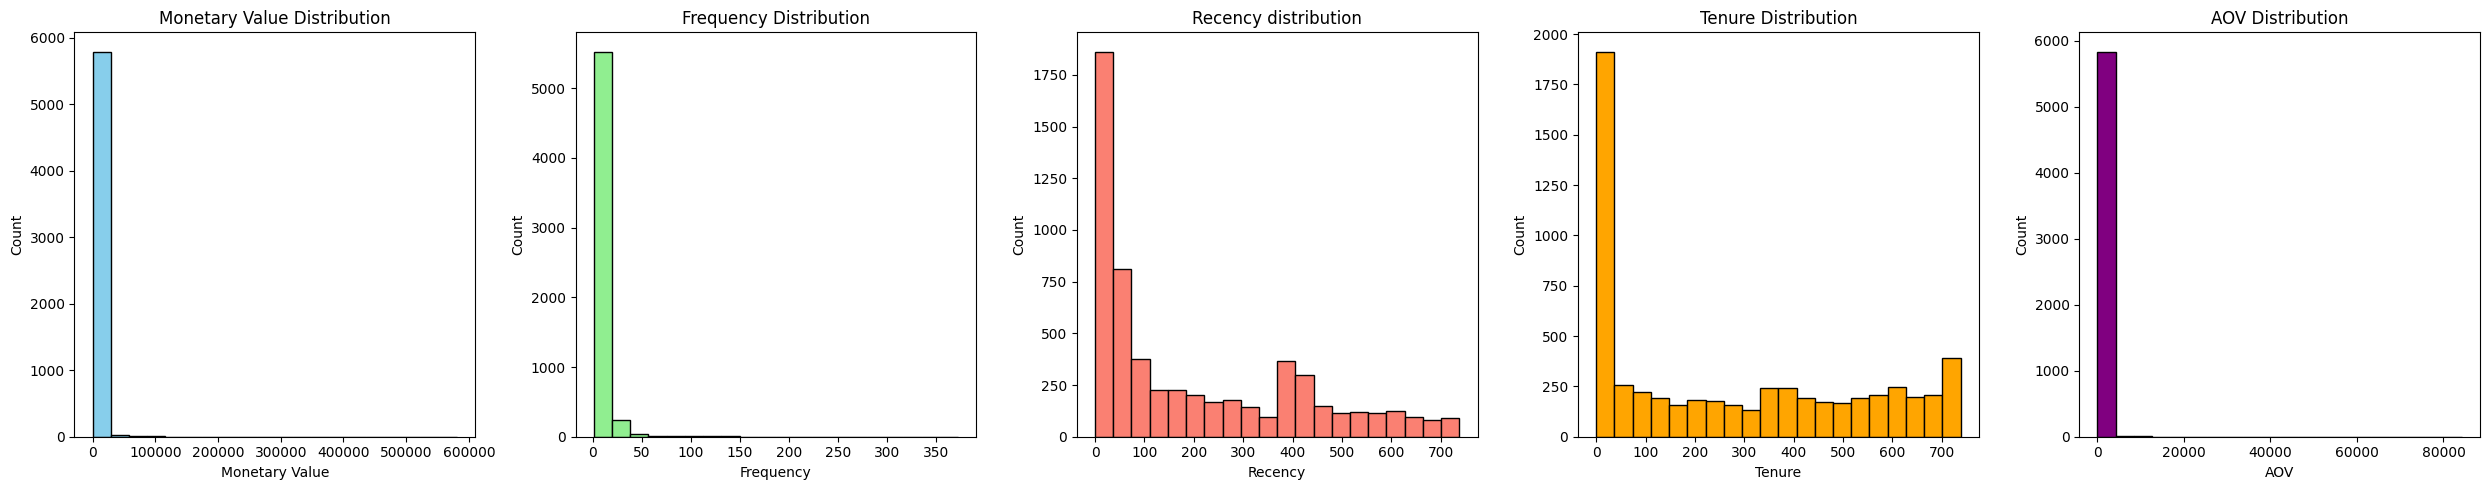

In [33]:
# shape/skewness visualization

plt.figure(figsize=(25, 5))

plt.subplot(1, 5, 1)
plt.hist(aggregated_df['MonetaryValue'], bins=20, color='skyblue', edgecolor='black')
plt.title('Monetary Value Distribution')
plt.xlabel('Monetary Value')
plt.ylabel('Count')

plt.subplot(1, 5, 2)
plt.hist(aggregated_df['Frequency'], bins=20, color='lightgreen', edgecolor='black')
plt.title('Frequency Distribution')
plt.xlabel('Frequency')
plt.ylabel('Count')

plt.subplot(1, 5, 3)
plt.hist(aggregated_df['Recency'], bins=20, color='salmon', edgecolor='black')
plt.title('Recency distribution')
plt.xlabel('Recency')
plt.ylabel('Count')

plt.subplot(1, 5, 4)
plt.hist(aggregated_df['Tenure'], bins=20, color='orange', edgecolor='black')
plt.title('Tenure Distribution')
plt.xlabel('Tenure')
plt.ylabel('Count')

plt.subplot(1, 5, 5)
plt.hist(aggregated_df['AOV'], bins=20, color='purple', edgecolor='black')
plt.title('AOV Distribution')
plt.xlabel('AOV')
plt.ylabel('Count')


plt.tight_layout()
plt.show()

ALL FEATURES ARE HEAVILY RIGHT-SKEWED

In [34]:
print("D'Agostino-Pearson Normality Test")
print("H0: data is normally distributed")

for col in ["MonetaryValue", "Frequency", "Recency", "Tenure", "AOV"]:
    stat, p = normaltest(aggregated_df[col].dropna())
    result = "NON-NORMAL ✓" if p < 0.05 else "NORMAL"
    print(f"{col}: stat={stat:.2f}, p={p:.2e} → {result}")

D'Agostino-Pearson Normality Test
H0: data is normally distributed
MonetaryValue: stat=14228.89, p=0.00e+00 → NON-NORMAL ✓
Frequency: stat=10169.07, p=0.00e+00 → NON-NORMAL ✓
Recency: stat=673.03, p=7.15e-147 → NON-NORMAL ✓
Tenure: stat=182910.74, p=0.00e+00 → NON-NORMAL ✓
AOV: stat=18926.86, p=0.00e+00 → NON-NORMAL ✓


ALL FEATURES ARE CONFIRMED HIGHLY SKEWED BY STATISTICAL TEST, PARTICULARLY TENURE, (p < 0.05) — HIGH SKEWNESS DISTORTS EUCLIDEAN DISTANCES FOR DISTANCE-BASED ALGORITHMS LIKE KMEANS → TRANSFORMATION IS REQUIRED

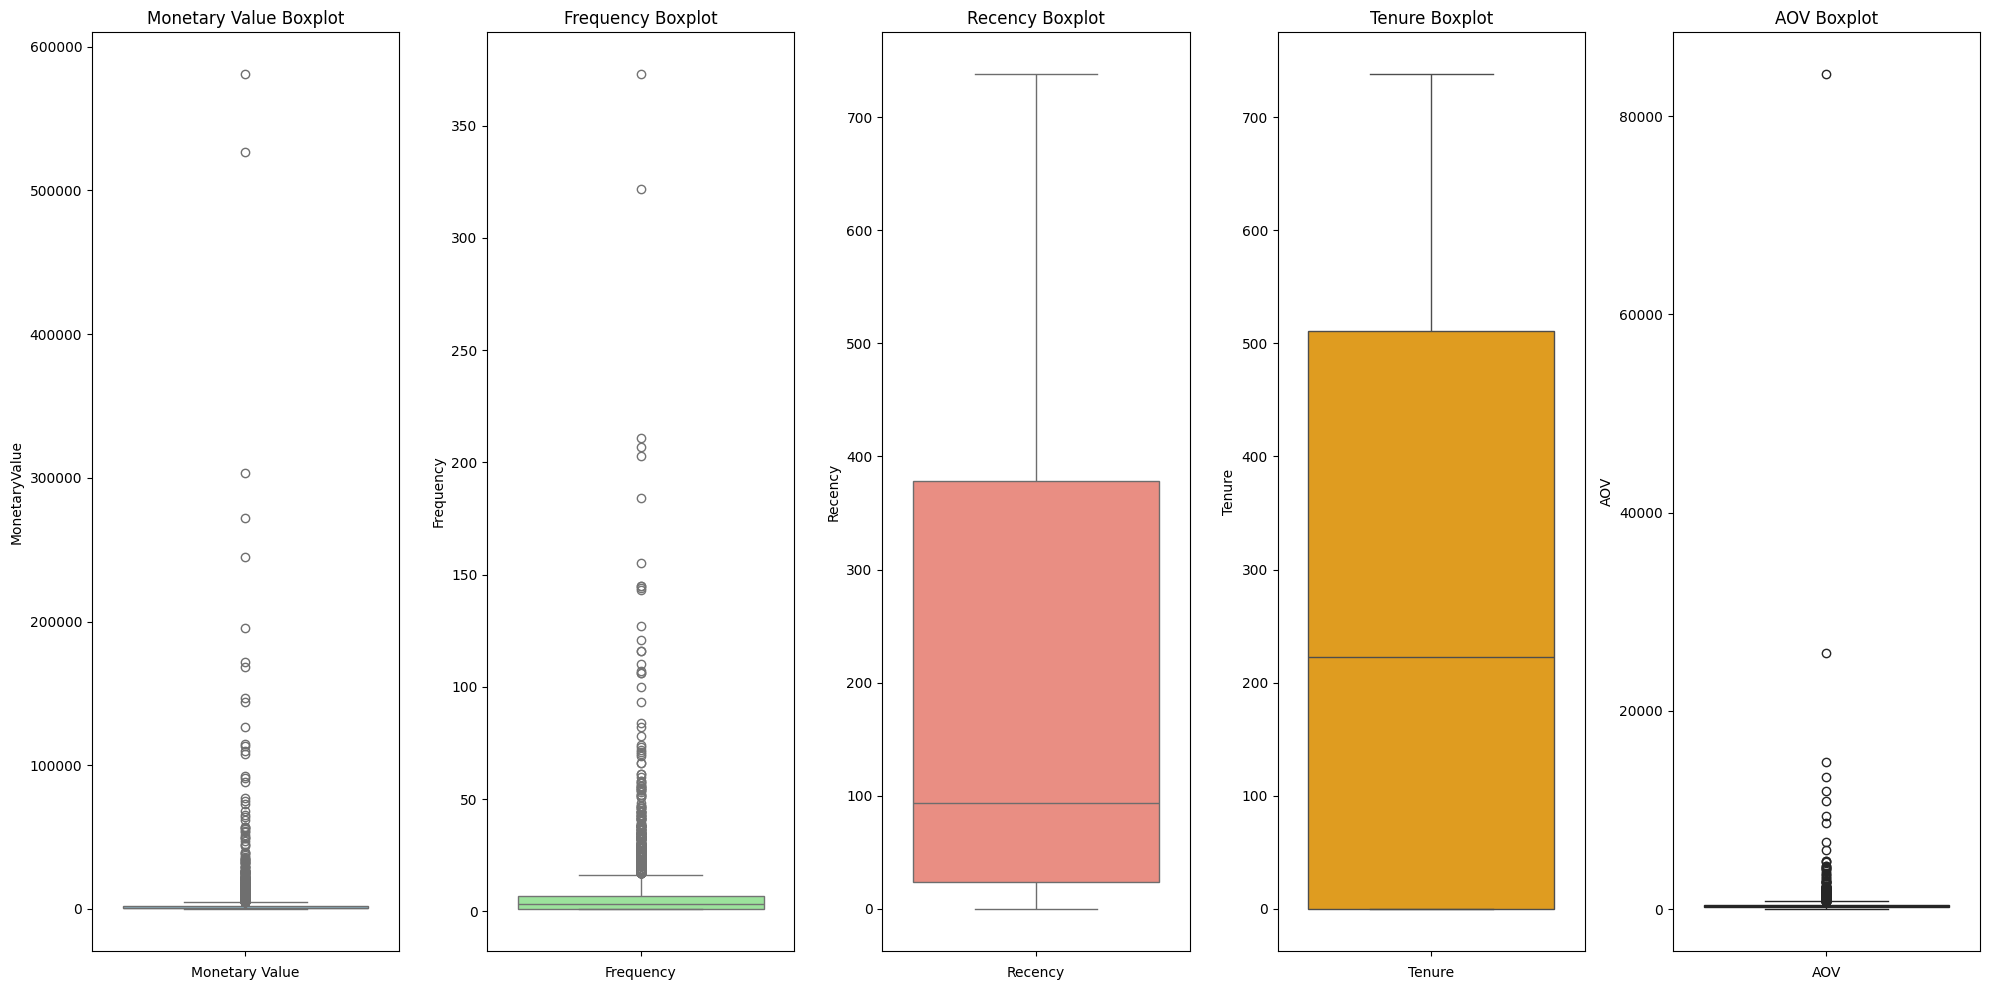

In [35]:
plt.figure(figsize=(20, 10))

plt.subplot(1, 5, 1)
sns.boxplot(data=aggregated_df['MonetaryValue'], color='skyblue')
plt.title('Monetary Value Boxplot')
plt.xlabel('Monetary Value')

plt.subplot(1, 5, 2)
sns.boxplot(data=aggregated_df['Frequency'], color='lightgreen')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency')

plt.subplot(1, 5, 3)
sns.boxplot(data=aggregated_df['Recency'], color='salmon')
plt.title('Recency Boxplot')
plt.xlabel('Recency')

plt.subplot(1, 5, 4)
sns.boxplot(data=aggregated_df['Tenure'], color='orange')
plt.title('Tenure Boxplot')
plt.xlabel('Tenure')

plt.subplot(1, 5, 5)
sns.boxplot(data=aggregated_df['AOV'], color='purple')
plt.title('AOV Boxplot')
plt.xlabel('AOV')

plt.tight_layout()
plt.show()


ALL FEATURES EXCEPT TENURE AND RECENCY HAVE OUTLIERS, BUT TENURE ALSO HAS HIGH VARIANCE (SOME CUSTOMERS ARE BRAND NEW, SOME ARE VETERANS), RECENCY SLIGHTLY SMALLER, BUT STILL HIGH (SOME BUY RECENTLY, SOME NOT) - BOTH HAVE LOGICAL AND NORMAL BEHAVIOR FOR USER SEGMENTATION

In [36]:
features = {
    "Recency": aggregated_df["Recency"],
    "MonetaryValue": aggregated_df["MonetaryValue"],
    "Frequency": aggregated_df["Frequency"],
    "Tenure": aggregated_df["Tenure"],
    "AOV": aggregated_df["AOV"],
}

for name, series in features.items():
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    mild_threshold = Q3 + 1.5 * IQR
    extreme_threshold = Q3 + 3.0 * IQR

    # All outliers
    outliers = aggregated_df[series > mild_threshold]

    # Mild only
    mild_outliers = aggregated_df[(series > mild_threshold) & (series <= extreme_threshold)]

    # Extreme
    extreme_outliers = aggregated_df[series > extreme_threshold]

    print(f"\n--- {name} ---")
    print(f"Total outliers (1.5×IQR): {len(outliers)}")
    print(f"Mild outliers: {len(mild_outliers)}")
    print(f"Extreme outliers: {len(extreme_outliers)}")

    if len(outliers) > 0:
        print(outliers[name].describe())


--- Recency ---
Total outliers (1.5×IQR): 0
Mild outliers: 0
Extreme outliers: 0

--- MonetaryValue ---
Total outliers (1.5×IQR): 619
Mild outliers: 253
Extreme outliers: 366
count      619.00
mean     17897.70
std      40932.19
min       5114.23
25%       6414.26
50%       8869.87
75%      14089.90
max     580987.04
Name: MonetaryValue, dtype: float64

--- Frequency ---
Total outliers (1.5×IQR): 424
Mild outliers: 220
Extreme outliers: 204
count   424.00
mean     34.87
std      34.68
min      17.00
25%      20.00
50%      25.00
75%      35.00
max     373.00
Name: Frequency, dtype: float64

--- Tenure ---
Total outliers (1.5×IQR): 0
Mild outliers: 0
Extreme outliers: 0

--- AOV ---
Total outliers (1.5×IQR): 384
Mild outliers: 226
Extreme outliers: 158
count     384.00
mean     1762.26
std      4655.96
min       765.18
25%       882.53
50%      1042.01
75%      1394.39
max     84236.25
Name: AOV, dtype: float64


TENURE WITH RECENCY HAS NO OUTLIERS

FREQUENCY, MONETARY, AND AOV DO HAVE THEM, PARTICULARLY MONETARY

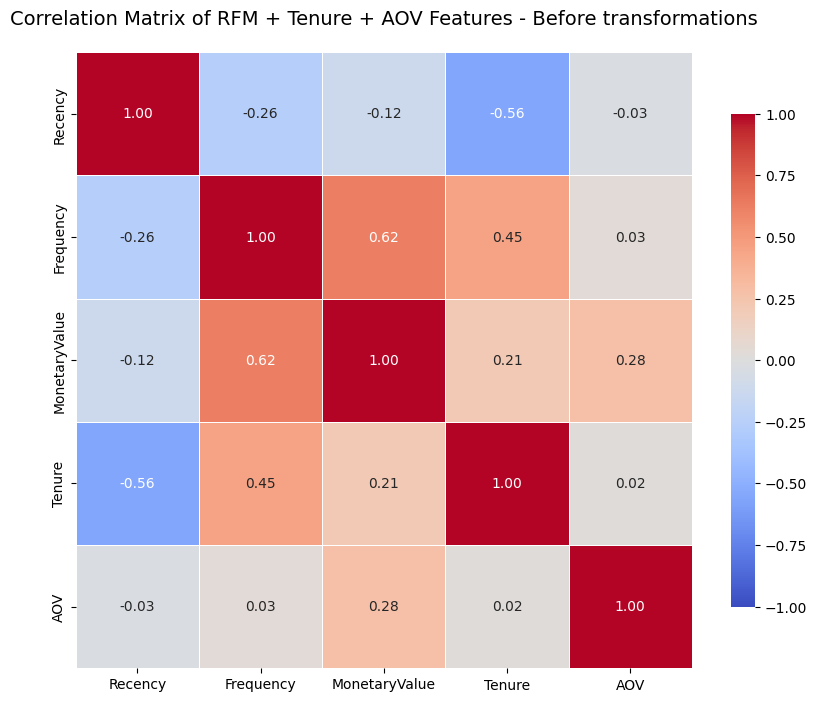

In [37]:
plt.figure(figsize=(10, 8))
corr = aggregated_df[['Recency', 'Frequency', 'MonetaryValue', 'Tenure', 'AOV']].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8}
)

plt.title("Correlation Matrix of RFM + Tenure + AOV Features - Before transformations", fontsize=14, pad=20)
plt.show()

NO STRONG MULTICOLINEARITY, ONLY MILD FOR FREQUENCY-MONETARY (0.62)

**CONCLUSIONS:** 

DATA IS HEAVILY RIGHT-SKEWED -  TRANSFORMATION IS NEEDED, 

MOST FEATURES HAVE SIGNIFICANT OUTLIERS - OUTLIER REMOVAL IS NEEDED, 

DATA IS ON DIFFERENT SCALES - NORMALIZATION IS NEEDED, 

MILD MULTICOLINEARITY FOR FREQUENCY-MONETARY, BUT IT'S BELOW 0.7 THRESHOLD.

<h2 style="text-align: center">OUTLIER DETECTION AND REMOVAL</h2>

In [38]:
M_Q1 = aggregated_df["MonetaryValue"].quantile(0.25)
M_Q3 = aggregated_df["MonetaryValue"].quantile(0.75)
M_IQR = M_Q3 - M_Q1


monetary_outliers_df = aggregated_df[(aggregated_df["MonetaryValue"] > (M_Q3 + 1.5 * M_IQR)) 
                                     
                                    | (aggregated_df["MonetaryValue"] < (M_Q1 - 1.5 * M_IQR))].copy()

monetary_outliers_df.describe()




,MonetaryValue,Frequency,Recency,Tenure,AOV
count,619.00,619.00,619.00,619.00,619.00
mean,17897.70,26.00,50.33,602.34,994.30
std,40932.19,31.15,101.67,158.46,3725.97
min,5114.23,1.00,0.00,0.00,135.38
25%,6414.26,12.00,4.00,548.00,366.89
50%,8869.87,18.00,16.00,659.00,509.72
75%,14089.90,29.00,48.00,718.00,784.42
max,580987.04,373.00,691.00,738.00,84236.25


In [39]:
F_Q1 = aggregated_df['Frequency'].quantile(0.25)
F_Q3 = aggregated_df['Frequency'].quantile(0.75)
F_IQR = F_Q3 - F_Q1


frequency_outliers_df = aggregated_df[(aggregated_df['Frequency'] > (F_Q3 + 1.5 * F_IQR)) 
                                      | (aggregated_df['Frequency'] < (F_Q1 - 1.5 * F_IQR))].copy()

frequency_outliers_df.describe()

,MonetaryValue,Frequency,Recency,Tenure,AOV
count,424.00,424.00,424.00,424.00,424.00
mean,20662.34,34.87,30.79,643.55,503.09
std,48336.15,34.68,70.63,122.86,559.02
min,1807.44,17.00,0.00,77.00,28.67
25%,6186.90,20.00,2.75,608.00,261.35
50%,9534.40,25.00,9.00,697.00,366.05
75%,16465.40,35.00,24.00,725.00,521.76
max,580987.04,373.00,575.00,738.00,6001.39


In [40]:
AOV_Q1 = aggregated_df['AOV'].quantile(0.25)
AOV_Q3 = aggregated_df['AOV'].quantile(0.75)
AOV_IQR = AOV_Q3 - AOV_Q1

aov_outliers_df = aggregated_df[(aggregated_df['AOV'] > (AOV_Q3 + 1.5 * AOV_IQR)) 
                                | (aggregated_df['AOV'] < (AOV_Q1 - 1.5 * AOV_IQR))].copy()

aov_outliers_df.describe()

,MonetaryValue,Frequency,Recency,Tenure,AOV
count,384.00,384.00,384.00,384.00,384.00
mean,16246.88,9.82,176.14,301.68,1762.26
std,49800.17,20.26,197.22,276.74,4655.96
min,768.24,1.00,0.00,0.00,765.18
25%,1706.61,1.00,21.00,0.00,882.53
50%,3927.12,3.00,77.00,295.00,1042.01
75%,11332.48,9.00,299.75,568.00,1394.39
max,580987.04,145.00,730.00,738.00,84236.25


In [41]:
non_outliers_df = aggregated_df[
    (~aggregated_df.index.isin(monetary_outliers_df.index)) & 
    (~aggregated_df.index.isin(frequency_outliers_df.index)) &
    (~aggregated_df.index.isin(aov_outliers_df.index))].copy()
non_outliers_df.describe()

,MonetaryValue,Frequency,Recency,Tenure,AOV
count,4948.00,4948.00,4948.00,4948.00,4948.00
mean,1061.60,3.76,218.19,234.00,274.37
std,1074.35,3.23,211.44,237.97,145.87
min,2.95,1.00,0.00,0.00,2.95
25%,300.59,1.00,32.00,0.00,163.33
50%,656.76,3.00,133.00,160.00,249.88
75%,1448.09,5.00,392.00,425.00,355.60
max,5087.86,16.00,738.00,736.00,761.38


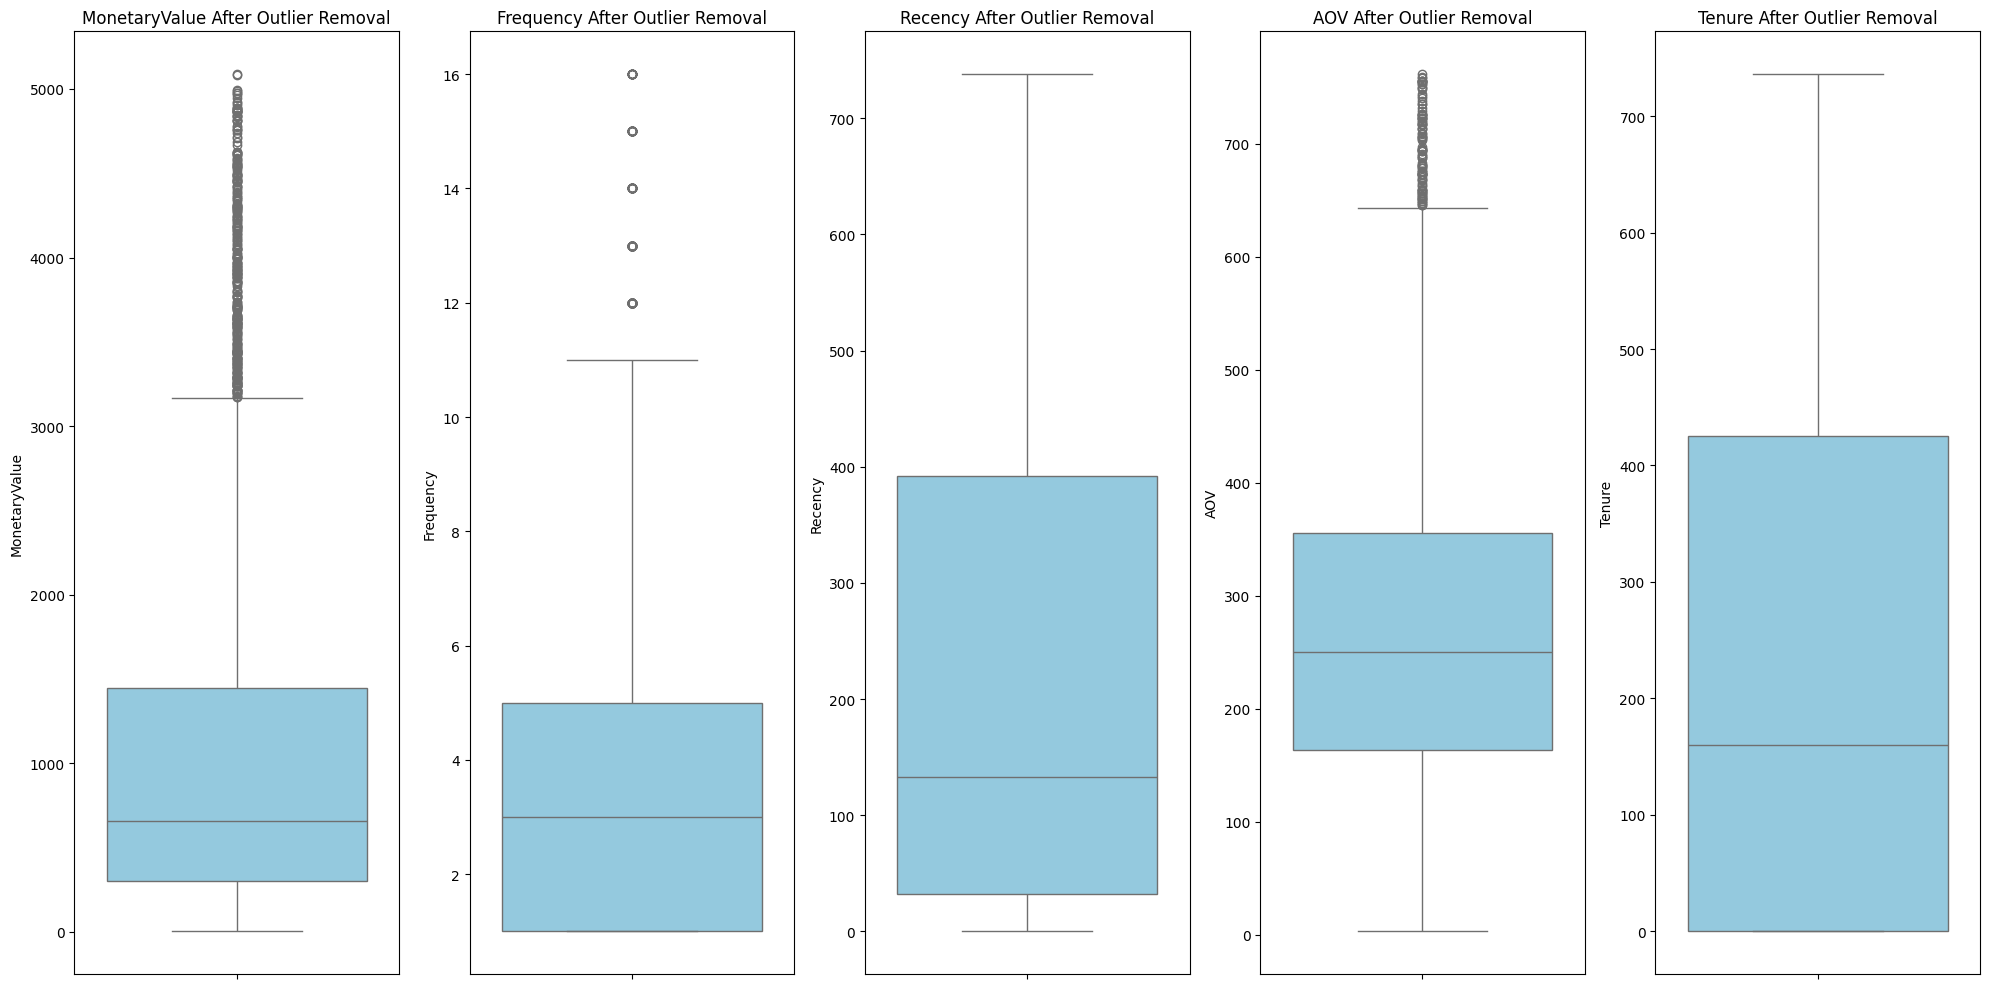

In [42]:
plt.figure(figsize=(20, 10))

for i, col in enumerate(["MonetaryValue", "Frequency", "Recency", "AOV", "Tenure"], 1):
    plt.subplot(1, 5, i)
    sns.boxplot(data=non_outliers_df[col], color='skyblue')
    plt.title(f'{col} After Outlier Removal')

plt.tight_layout()
plt.show()

**CONCLUSION:** THE NUMBER OF OUTLIERS HAS DECREASED, THE REMAINING OUTLIERS  - POWER TRANSFORMATION SHOULD HANDLE BY COMPRESSING EXTREME VALUES TOWARD THE CENTER SO IT WILL NOT DISTORT THE ALGORITHM

**POWER TRANSFORMATION:** 

In [43]:
cols = ["MonetaryValue", "Frequency", "Recency", "Tenure", "AOV"]
pt = PowerTransformer(method='yeo-johnson')
transformed_df = non_outliers_df[cols].copy()
transformed_df[cols] = pt.fit_transform(non_outliers_df[cols])

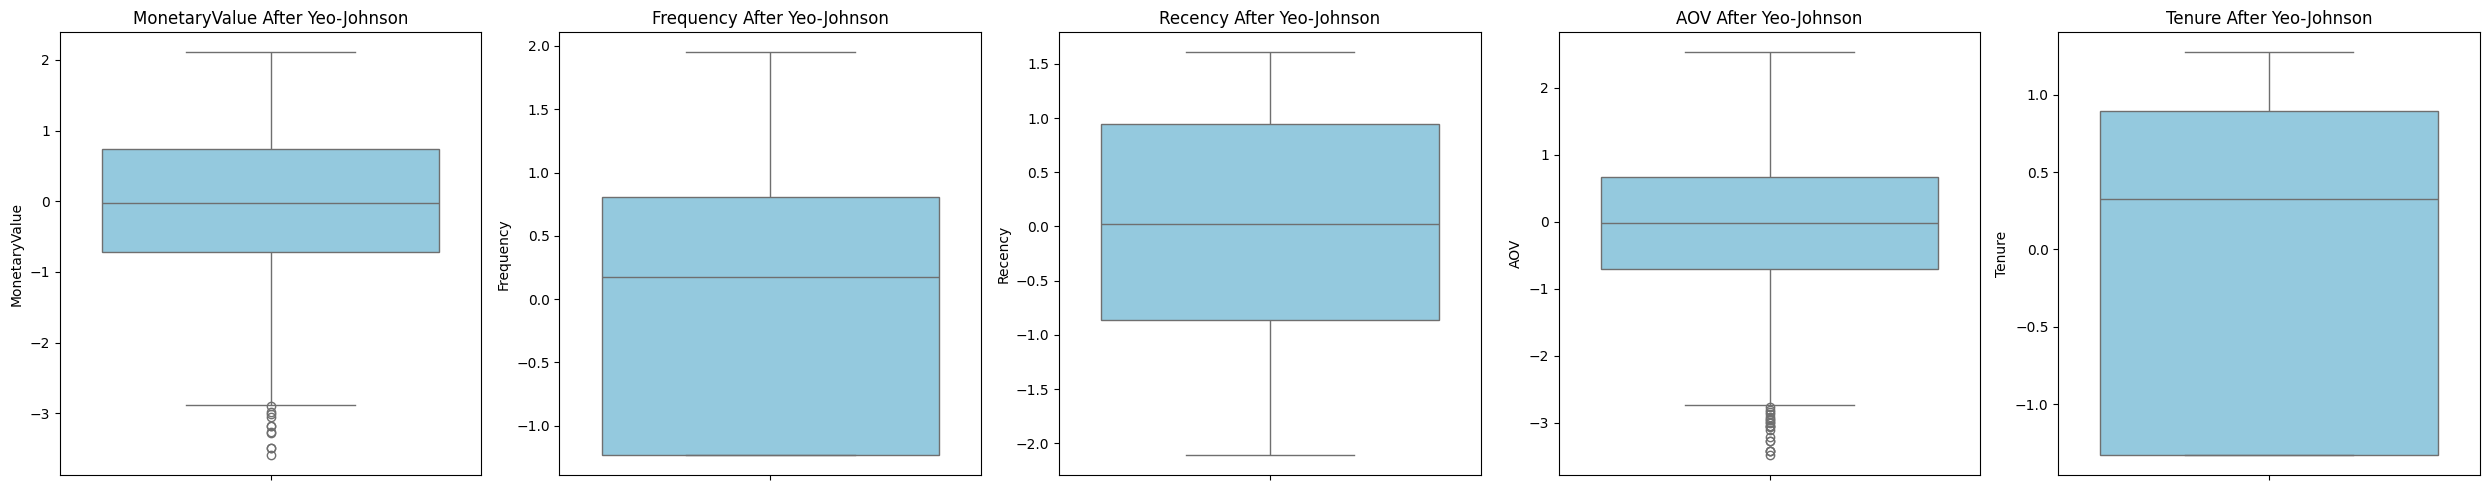

In [44]:
plt.figure(figsize=(25, 5))

for i, col in enumerate(["MonetaryValue", "Frequency", "Recency", "AOV", "Tenure"], 1):
    plt.subplot(1, 5, i)
    sns.boxplot(data=transformed_df[col], color='skyblue')
    plt.title(f'{col} After Yeo-Johnson')

plt.tight_layout()
plt.show()

IT WORKED, BUT SLIGHT MONETARY AND AOV OUTLIERS STILL REMAINED (MAINLY LOWER SIDES)

In [45]:
# Modified Z-score method using median and MAD, which is more robust to skewness - below the skewness after Yeo-Johnson is shown.

for col in ["MonetaryValue", "Frequency", "Recency", "AOV"]:
    median = transformed_df[col].median()
    mad = median_abs_deviation(transformed_df[col])
    robust_z = np.abs((transformed_df[col] - median) / mad)
    print(f"{col}: {(robust_z > 3.5).sum()} outliers")

MonetaryValue: 21 outliers
Frequency: 0 outliers
Recency: 0 outliers
AOV: 72 outliers


In [46]:
for col in ["MonetaryValue", "AOV"]:
    median = transformed_df[col].median()
    mad = median_abs_deviation(transformed_df[col])
    robust_z = np.abs((transformed_df[col] - median) / mad)
    print(f"\n{col}:")
    print(transformed_df[col][robust_z > 3.5].describe())


MonetaryValue:
count   21.00
mean    -2.98
std      0.31
min     -3.59
25%     -3.18
50%     -2.90
75%     -2.72
max     -2.59
Name: MonetaryValue, dtype: float64

AOV:
count   72.00
mean    -0.84
std      2.59
min     -3.49
25%     -2.82
50%     -2.50
75%      2.43
max      2.53
Name: AOV, dtype: float64


THESE OUTLIERS EXIST IN TRANSFORMED SPACE AND YEO-JOHNSON ALREADY COMPRESSED THEM SIGNIFICANTLY. OUT OF 4,948 CUSTOMERS — 21 AND 72 OUTLIERS ARE 0.4% AND 1.5% OF THE DATASET, THEY EXIST ON THE LOWER TAIL — LOW-SPENDING CUSTOMERS WHO WON'T FORM A SEPARATE CLUSTER OR PULL CENTROIDS MEANINGFULLY, SO THEY WILL NOT HAVE A MEANINGFUL IMPACT ON CLUSTERS, SO THEY CAN BE LEFT.

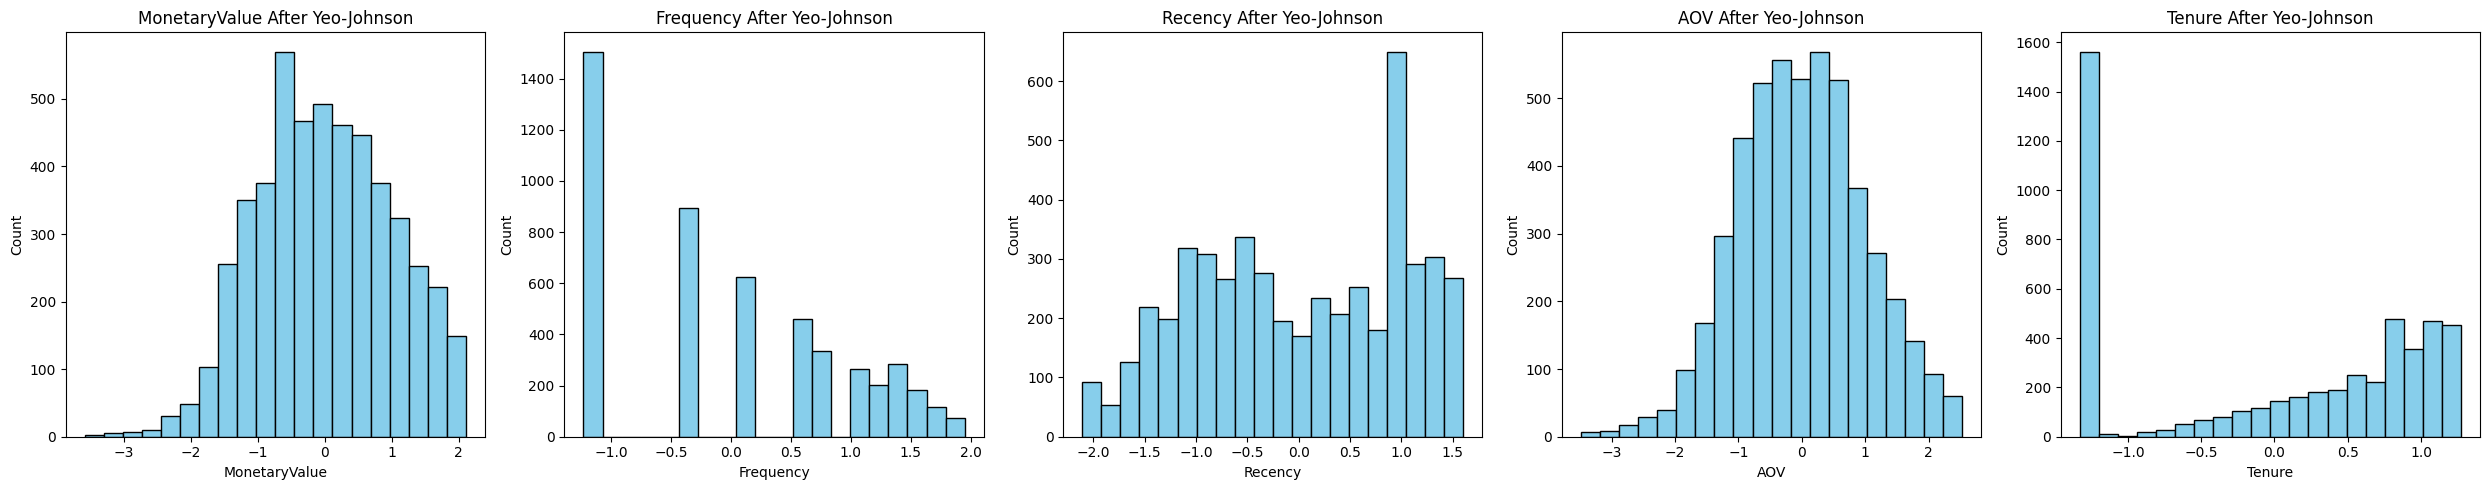

In [47]:
plt.figure(figsize=(25, 5))

for i, col in enumerate(["MonetaryValue", "Frequency", "Recency", "AOV", "Tenure"], 1):
    plt.subplot(1, 5, i)
    plt.hist(transformed_df[col], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'{col} After Yeo-Johnson')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

MONETARY AND AOV ROUGHLY NORMALLY DISTRIBUTED,

RECENCY IS ROUGHLY UNIFORM WITH A SHARP PEAK NEAR 1 — YEO-JOHNSON FLATTENED THE ORIGINAL RIGHT SKEW MUCH

FREQUENCY HAS HIGHER RIGHT SKEW (MOST CUSTOMERS BUY FEW TIMES, FEW BUY MANY)

TENURE HAS THOUSANDS OF CUSTOMERS WITH EXACTLY 0 DAYS (SAME-DAY BUYERS) WHICH YEO-JOHNSON MAPS TO -1.0

In [48]:
non_outliers_df["Frequency"].value_counts().head(10)

Frequency
1     1506
2      895
3      623
4      460
5      337
6      264
7      202
8      155
9      130
11      99
Name: count, dtype: int64

FREQUENCY ADDITIONALLY IS A GRADUAL DECAY - NATURAL CUSTOMER BEHAVIOR, WHERE MOST BUY INFREQUENTLY, LESS IMPACTFUL FOR CLUSTERS

In [49]:
non_outliers_df["Tenure"].value_counts().head(10)

Tenure
0      1562
20       16
707      15
366      14
363      14
362      13
104      12
349      12
82       12
573      12
Name: count, dtype: int64

TENURE HAS A MASSIVE SPIKE AT 0 DAYS (~1562 CUSTOMERS).

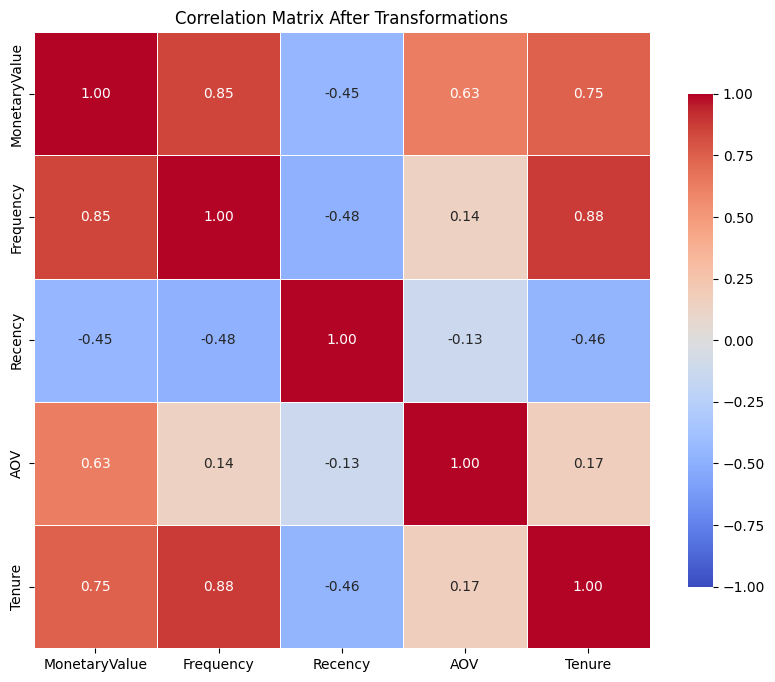

In [50]:
plt.figure(figsize=(10, 8))
corr = transformed_df[["MonetaryValue", "Frequency", "Recency", "AOV", "Tenure"]].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8}
)

plt.title("Correlation Matrix After Transformations")
plt.show()

TENURE IS HIGHLY CORRELATED WITH FREQUENCY (0.88) AND MONETARYVALUE (0.75)

FREQUENCY ALSO HAS HIGH MULTICOLINEARITY WITH MONETARY (0.85) AND TENURE (0.75)

FROM THE DATA STANDPOINT BOTH FREQUENCY AND TENURE ARE PROBLEMATIC. TENURE HAS A MASSIVE PEAK AND IS HEAVILY RIGHTLY SKEWED AND IS HIGHLY MULTICOLINEAR WITH OTHER FEATURES, WHEREAS FREQUENCY IS MID-HIGHER RIGHLY SKEWED, BUT HAS A GRADUAL DECREASE, AND HAS INSIGNIFICANTLY SMALLER MULTICOLINEARITY WITH OTHER FEATURES, BUT STILL HIGH. OUT OF THIS TWO FREQUENCY IS BETTER, ESPECIALLY GIVEN GRADUAL DECREASE.

FROM THE BUSINESS STANDPOINT, TENURE IS A PASSIVE METRIC. IT TELLS HOW LONG SOMEONE HAS BEEN A CUSTOMER, BUT IT DOESN'T INDICATE THEIR CURRENT INTENT TO BUY OR THEIR VALUE, SO IT IS LESS VALUABLE FOR MARKETING TEAM TO TARGET, WHEREAS FREQUENCY IS A STANDARD FOR RFM CLUSTERING, AND MOST IMPORTANTLY AFTER FURTHER EXPERIMENTATION IN THIS PROJECT WITHOUT IT AND IMPORTANT DISTINCTION OF TWO CLUSTERS AND FOLLOWING THE STRATEGY FOR THEM TWO WOULD BE MERGED.


CONCLUSION: TENURE SHOULD BE DROPPED

In [51]:
transformed_df.drop(columns=["Tenure"], inplace=True)

transformed_df

,MonetaryValue,Frequency,Recency,AOV
1,2.07,1.32,-1.94,1.95
2,0.88,0.81,-0.38,0.52
4,-0.73,-1.23,0.72,0.29
5,-0.71,-1.23,0.90,0.33
6,0.92,1.44,-0.81,-0.46
...,...,...,...,...
5846,-1.14,-0.35,-1.50,-1.50
5848,-0.44,-1.23,1.04,0.98
5849,-0.52,-1.23,1.48,0.79
5850,0.59,-0.35,1.14,1.98


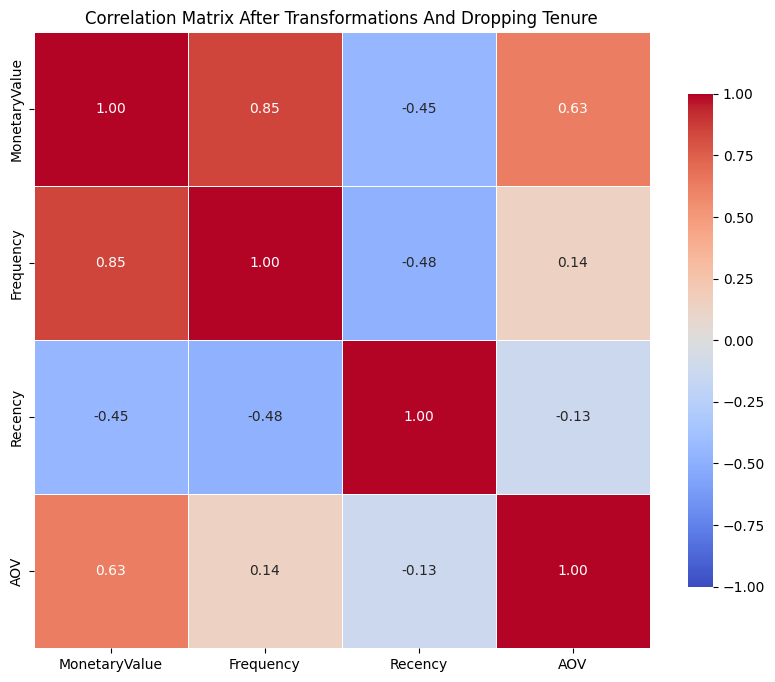

In [52]:
plt.figure(figsize=(10, 8))
corr = transformed_df[["MonetaryValue", "Frequency", "Recency", "AOV"]].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8}
)

plt.title("Correlation Matrix After Transformations And Dropping Tenure")
plt.show()

MONETARYVALUE ↔ FREQUENCY: 0.85 — VERY HIGH, CUSTOMERS WHO BUY OFTEN ALSO SPEND MORE. THIS MULTICOLLINEARITY WILL BE PARTIALLY HANDLED BY PCA, WHICH DECORRELATES FEATURES BEFORE FEEDING INTO KMEANS.

NOTE: MONETARYVALUE = AOV × FREQUENCY IS A MATHEMATICAL IDENTITY, NOT JUST CORRELATION. BOTH ARE RETAINED AS THEY CAPTURE DIFFERENT SPENDING DIMENSIONS — TOTAL SPEND VS SPEND PER ORDER AND THEREFORE THEIR DISTINCTION IS IMPORTANT FROM THE BUSINESS PERCPECTIVE. 


MONETARYVALUE ↔ AOV: 0.63 — MODERATE, EXPECTED.

RECENCY ↔ FREQUENCY: -0.48 AND RECENCY ↔ MONETARYVALUE: -0.45 — MAKES SENSE, INACTIVE CUSTOMERS BUY LESS AND SPEND LESS.

AOV ↔ FREQUENCY: 0.13 AND AOV ↔ RECENCY: -0.13 — AOV IS NEARLY INDEPENDENT - ADDS UNIQUE INFORMATION.

In [53]:
pca_check = PCA()
pca_check.fit(transformed_df)
print(np.cumsum(pca_check.explained_variance_ratio_))

[0.6059085  0.85123123 0.99842116 1.        ]


3 COMPONENTS EXPLAIN ALMOST 100% OF THE DATA

In [ ]:
# 4TH COMPONENT EXPLAINS ONLY 0.16% OF VARIANCE — DROPPED AS NOISE.
# PCA USED PRIMARILY FOR DECORRELATION (FREQUENCY↔MONETARY r=0.85),
# DIMENSIONALITY REDUCTION IS A SECONDARY BENEFIT.

pca = PCA(n_components=3)
pca_data = pca.fit_transform(transformed_df)

loadings = pd.DataFrame(
    pca.components_,
    columns=transformed_df.columns,
    index=['PC1', 'PC2', 'PC3']
)
print(loadings)
print(f"\nExplained variance ratio: {pca.explained_variance_ratio_}")

     MonetaryValue  Frequency  Recency   AOV
PC1           0.62       0.55    -0.42  0.37
PC2           0.15      -0.34     0.49  0.79
PC3           0.24       0.51     0.77 -0.30

Explained variance ratio: [0.6059085  0.24532273 0.14718993]


<h2 style="text-align: center">K-MEANS CLUSTERING</h2>

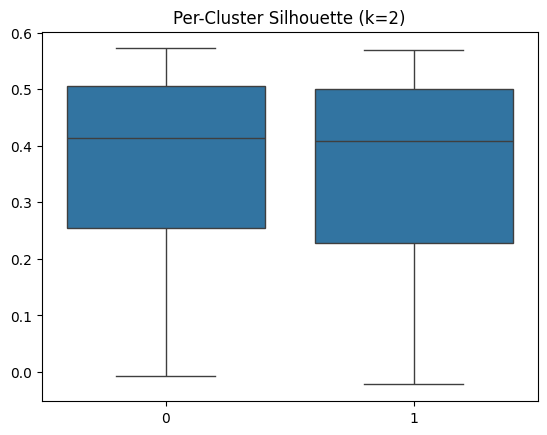

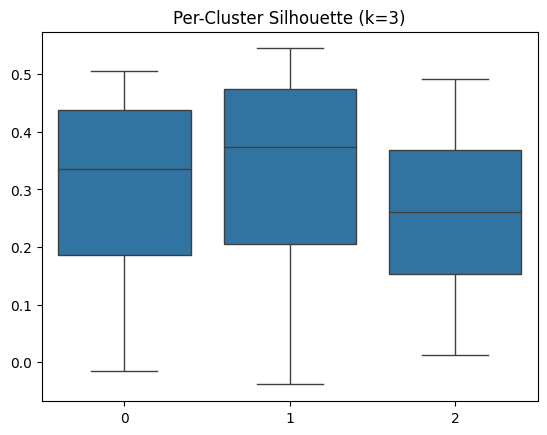

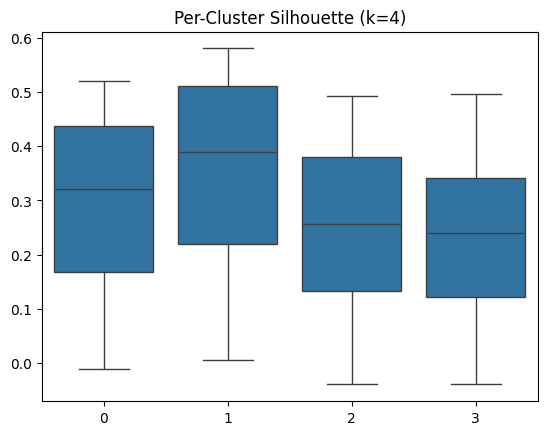

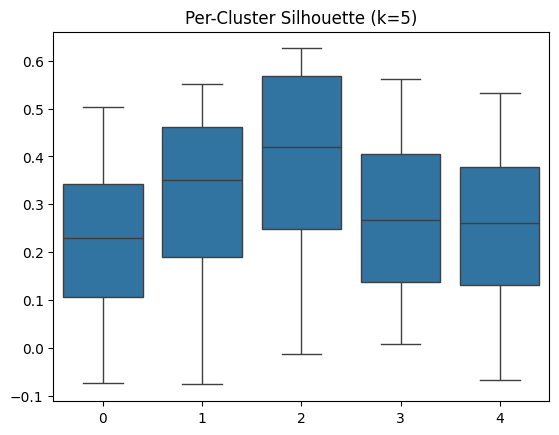

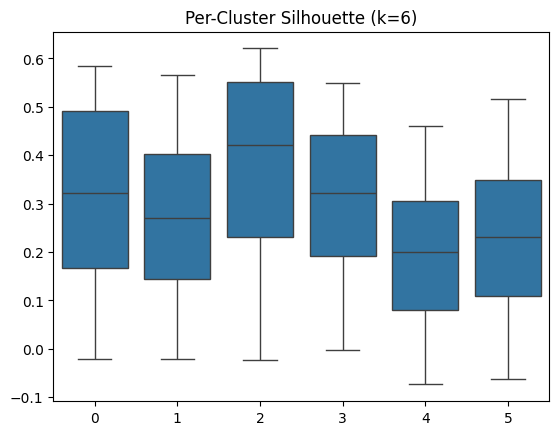

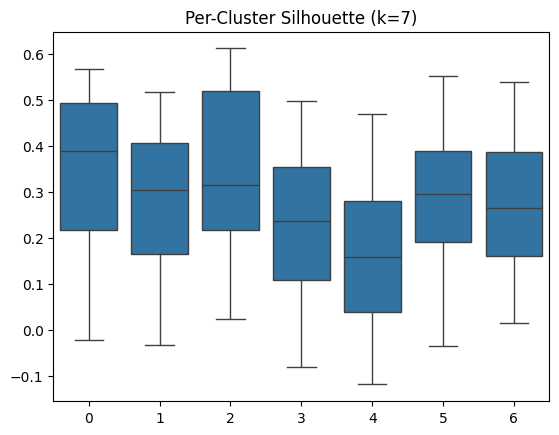

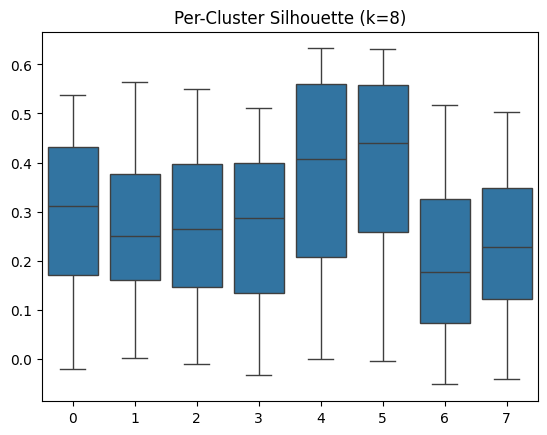

In [55]:
max_k = 8
inertia = []
silhouette_scores = []
k_values = range(2, max_k + 1)

for k in k_values:

    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=50, n_init=50)
    cluster_labels = kmeans.fit_predict(pca_data)
    sil_score = silhouette_score(pca_data, cluster_labels)
    silhouette_scores.append(sil_score)
    inertia.append(kmeans.inertia_)

    sample_sil_values = silhouette_samples(pca_data, cluster_labels)
    sns.boxplot(x=cluster_labels, y=sample_sil_values)
    plt.title(f"Per-Cluster Silhouette (k={k})")
    plt.show()

K=2: BOTH CLUSTERS STRONG (IQR 0.3–0.5, MEDIANS ~0.4). NO NEGATIVES. STATISTICALLY BEST BUT USELESS FOR BUSINESS — ONLY 2 SEGMENTS.

K=3: THREE SOLID CLUSTERS (IQR 0.2–0.5, MEDIANS ~0.35). NO NEGATIVES. STILL TOO COARSE.

K=4: ALL 4 CLUSTERS HEALTHY (IQR 0.2–0.5). CLUSTER 1 STRONGEST (MEDIAN ~0.4, TIGHT IQR). NO NEGATIVES ANYWHERE. MOST CONSISTENT DISTRIBUTION ACROSS ALL K VALUES.

K=5: CLUSTER 2 STRONGEST (IQR 0.3–0.6). CLUSTER 0 CLEARLY WEAK — WHISKERS REACH -0.1, IQR DROPS TO 0.1–0.3. FIRST APPEARANCE OF NEGATIVE SILHOUETTE VALUES — ONE CLUSTER HAS AMBIGUOUS BOUNDARIES.

K=6: CLUSTERS 4 AND 5 NOTICEABLY WEAKER. WHISKERS TO -0.1. SCORES MORE SPREAD AND INCONSISTENT.

K=7: CLUSTERS 3 AND 4 PARTICULARLY WEAK WITH NEGATIVE VALUES. MULTIPLE CLUSTERS BELOW 0.2 MEDIAN.

K=8: CLUSTERS 4 AND 5 ARTIFICIALLY HIGH BUT CLUSTERS 6 AND 7 COLLAPSE. UNEVEN QUALITY — FORCED SPLITTING.

CONCLUSION: K=4, K=5 AND K=6 SHOULD EXAMINED. FINAL DECISION REQUIRES INSPECTING CLUSTER MEANS AND BUSINESS INTERPRETABILITY — DONE IN THE NEXT SECTION.

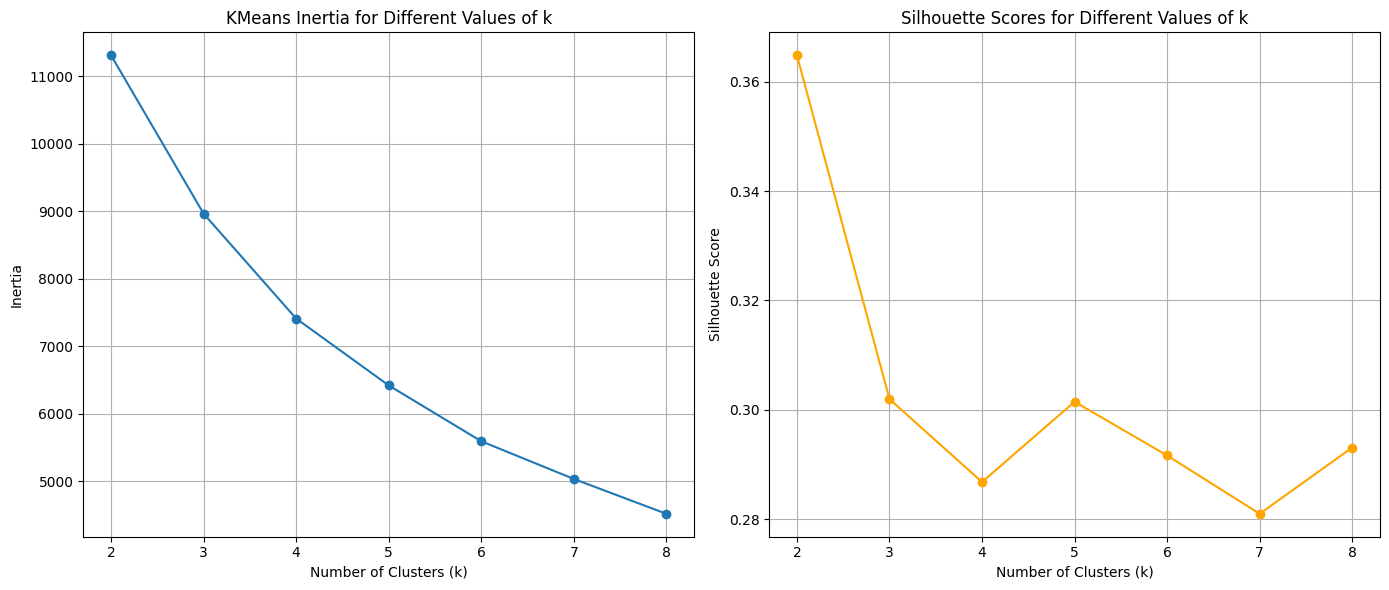

In [56]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(k_values, inertia, marker='o')
plt.title('KMeans Inertia for Different Values of k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Scores for Different Values of k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.show()

INERTIA: NO CLEAR ELBOW, SLOWS SLIGHTLY AFTER K=5-6

SILHOUETTE: SHARP DECLINE FROM K=2, HITS LOWEST AT K=4, THEN K=5 HIGHER, AND GRADUALLY DECLINES AFTER IT, BUT STILL K=6 HAS HIGHER THAN K=4

SO FAR BASED ON PER-CLUSTER SILHOUETTE, INERTIA AND SILHOUETTE SCORE, THE MOST OPTIMAL FROM STATISTICAL POINT OF VIEW IS K=2, BUT HIGHLY IMPRACTICAL. K=3 IS REALISTIC BUT LIMITED FROM A BUSINESS PERSPECTIVE. OF THE REMAINING CANDIDATES, K=4 HAS THE LOWEST GLOBAL SILHOUETTE SCORE AMONG THE THREE, K=5 HAS THE WEAKEST PER-CLUSTER DISTRIBUTION WITH CLUSTER 0 REACHING NEGATIVE VALUES, AND K=6 IS CLEANER PER-CLUSTER THAN K=5 BUT HAS LOWER GLOBAL SILHOUETTE SCORE AND DIMINISHING INERTIA GAINS — FINAL CHOICE REQUIRES BUSINESS INTERPRETATION OF CLUSTER MEANS.

In [57]:
for k in [3, 4, 5, 6]:
    km = KMeans(n_clusters=k, max_iter=50, random_state=42, n_init=50)
    labels = km.fit_predict(pca_data)
    print(f"k={k}: Silhouette={silhouette_score(pca_data, labels):.4f}, Davies-Bouldin={davies_bouldin_score(pca_data, labels):.4f}, Calinski-Harabasz={calinski_harabasz_score(pca_data, labels):.4f}")

k=3: Silhouette=0.3020, Davies-Bouldin=1.1963, Calinski-Harabasz=2978.8840
k=4: Silhouette=0.2868, Davies-Bouldin=1.1663, Calinski-Harabasz=2746.8959
k=5: Silhouette=0.3015, Davies-Bouldin=1.0566, Calinski-Harabasz=2567.9711
k=6: Silhouette=0.2916, Davies-Bouldin=1.0966, Calinski-Harabasz=2503.7549


NO METRIC UNANIMOUSLY AGREES. K=3 WINS SILHOUETTE AND CALINSKI-HARABASZ, K=5 WINS DAVIES-BOULDIN. STATISTICS ALONE CANNOT DECIDE — BUSINESS EXAMINATION OF CLUSTER MEANS IS REQUIRED.

K=3 AND K=6 ARE ELIMINATED — K=3 MERGES DISTINCTLY DIFFERENT CUSTOMER GROUPS, K=6 IS WEAKER THAN K=5 ACROSS ALL THREE METRICS.

COMPARING K=4 VS K=5: TWO OUT OF THREE METRICS FAVOR K=5. CALINSKI-HARABASZ DIFFERENCE IS NEGLIGIBLE (~7%). K=5 PER-CLUSTER SILHOUETTE SHOWS ONE WEAK CLUSTER BUT K=4 WINS ZERO METRICS.

CONCLUSION: K=5 IS THE OPTIMAL CHOICE — STATISTICALLY COMPETITIVE, IT WINS TWO OF THREE METRICS (SILHOUETTE VS. DAVIES–BOULDIN TRADE-OFF), WHILE THE CALINSKI–HARABASZ DIFFERENCE IS NEGLIGIBLE. DESPITE ONE WEAKER CLUSTER, K=5 PRESERVES MEANINGFUL CUSTOMER SEGMENTATION BETTER THAN K=4 AND AVOIDS THE OVERSIMPLIFICATION OF K=3 + BASED ON LATER BUSINESS FACTORS K=4, WOULD MERGE A TWO DISTINCTFUL CLUSTERS.

In [58]:
base = KMeans(n_clusters=5, random_state=42, max_iter=50, n_init=50).fit_predict(pca_data)

for seed in [0, 7, 123, 999]:
    labels = KMeans(n_clusters=5, random_state=seed, max_iter=50, n_init=50).fit_predict(pca_data)
    print(f"seed={seed}: ARI={adjusted_rand_score(base, labels):.4f}")

seed=0: ARI=1.0000
seed=7: ARI=0.9927
seed=123: ARI=0.9967
seed=999: ARI=0.9952


CLUSTER ASSIGNMENTS ARE HIGHLY STABLE ACROSS ALL SEEDS (ARI ≥ 0.99). n_init=50 ENSURES THE ALGORITHM CONSISTENTLY ESCAPES LOCAL OPTIMA. THE MODEL IS ROBUST AND DETERMINISTIC IN PRACTICE.


In [59]:
kmeans = KMeans(n_clusters=5, random_state=42, max_iter=50, n_init=50)
cluster_labels = kmeans.fit_predict(pca_data)
cluster_labels

array([1, 1, 4, ..., 4, 4, 1], shape=(4948,), dtype=int32)

In [60]:
for max_iter in [10, 20, 30, 40, 50]:
    km = KMeans(n_clusters=5, random_state=42, max_iter=max_iter, n_init=50)
    km.fit(pca_data)
    print(f"max_iter={max_iter}: converged in {km.n_iter_} iterations")

max_iter=10: converged in 10 iterations
max_iter=20: converged in 14 iterations
max_iter=30: converged in 14 iterations
max_iter=40: converged in 14 iterations
max_iter=50: converged in 14 iterations


ALTHOUGH CONVERGES AT 14 AND MAX_ITER=20 WOULD BE ENOUGH, 50 IS NICE SAFETY NET AND COSTS ALMOST NOTHING

In [61]:
non_outliers_df["Cluster"] = cluster_labels
non_outliers_df

,Customer ID,MonetaryValue,Frequency,Recency,Tenure,AOV,Cluster
1,12347,4921.53,8,1,402,615.19,1
2,12348,1658.40,5,74,362,331.68,1
4,12350,294.40,1,309,0,294.40,4
5,12351,300.93,1,374,0,300.93,4
6,12352,1729.54,9,35,356,192.17,1
...,...,...,...,...,...,...,...
5846,18282,178.05,2,7,118,89.03,0
5848,18284,411.68,1,431,0,411.68,4
5849,18285,377.00,1,660,0,377.00,4
5850,18286,1246.43,2,476,247,623.22,4


In [62]:
print(non_outliers_df.groupby("Cluster")[["MonetaryValue", "Frequency", "Recency", "AOV"]].mean())

         MonetaryValue  Frequency  Recency    AOV
Cluster                                          
0               520.80       2.71    31.46 209.88
1              2460.64       7.50    55.04 354.83
2               164.77       1.25   409.80 137.70
3               900.76       4.33   299.15 216.03
4               663.31       1.52   345.56 426.32


**QUICK SUMMARY OF THE RESULTS ABOVE**:

CLUSTER 0 — MID SPEND, MID FREQUENCY, VERY RECENT, LOW AOV → LOYAL (FREQUENT AND RECENT BUT LOWER SPEND PER ORDER)

CLUSTER 1 — HIGH SPEND, HIGH FREQUENCY, RECENT, HIGH AOV → VIP (BEST CUSTOMERS, ACTIVE, FREQUENT, HIGH VALUE)

CLUSTER 2 — LOW SPEND, LOW FREQUENCY, VERY HIGH RECENCY, LOW AOV → CHURNED (INACTIVE, RARE, LOW VALUE)

CLUSTER 3 — MID SPEND, MID FREQUENCY, HIGH RECENCY, LOW AOV → AT-RISK FREQUENT (WAS A REGULAR BUYER, NOW DISENGAGED — NEEDS VOLUME INCENTIVES)

CLUSTER 4 — MID SPEND, LOW FREQUENCY, HIGH RECENCY, HIGH AOV → AT-RISK HIGH-VALUE (RARE BUT HIGH-SPEND BUYER, NOW DISENGAGED — NEEDS PREMIUM RE-ENGAGEMENT)

In [63]:
km_k4 = KMeans(n_clusters=4, random_state=42, max_iter=50, n_init=50)
labels_k4 = km_k4.fit_predict(pca_data)
raw_with_k4 = aggregated_df.loc[non_outliers_df.index].copy()
raw_with_k4["Cluster"] = labels_k4
print(raw_with_k4.groupby("Cluster")[["MonetaryValue", "Frequency", "Recency", "AOV"]].mean())

         MonetaryValue  Frequency  Recency    AOV
Cluster                                          
0              2482.95       7.45    75.05 361.86
1               183.26       1.35   376.20 141.75
2               682.04       1.79   332.07 390.25
3               714.03       4.04    99.03 189.85


K=4 MERGES AT-RISK FREQUENT AND AT-RISK HIGH-VALUE INTO ONE AT-RISK CLUSTER. 
DESPITE SIMILAR RECENCY (~300-345 DAYS), THEY DIFFER CRITICALLY:
AOV: £426 VS £216 — AT-RISK HIGH-VALUE SPENDS 2X PER ORDER
FREQUENCY: 4.33 VS 1.52 — AT-RISK FREQUENT WAS A REGULAR BUYER, AT-RISK HIGH-VALUE WAS ALWAYS A RARE BUYER
MERGING THEM LEADS TO WRONG MARKETING STRATEGY — AT-RISK FREQUENT NEEDS VOLUME 
INCENTIVES, AT-RISK HIGH-VALUE NEEDS PREMIUM RE-ENGAGEMENT. K=5 PRESERVES THIS DISTINCTION.

**CONCLUSION**: 

K=5 SEEMS THE OPTIMAL CHOICE BETWEEN BUSINESS GOALS AND STATISTICAL SCORE - BASED ON PREVIOUSLY EXPLAINED FACTS, K=3 IS TOO NARROW IN BUSINESS TERMS, ADDITIONALY TO THAT, K=4 WOULD MERGE DISTINCTFUL CLUSTERS WHICH FROM THE BUSINESS POINT OF VIEW WOULD BE SIGNIFICANT, SO IT IS THE MOST OPTIMAL CHOICE.

In [64]:
cluster_means = non_outliers_df.groupby("Cluster")[["MonetaryValue", "Frequency", "Recency", "AOV"]].mean()

vip_cluster = cluster_means["MonetaryValue"].idxmax()
churned_cluster = cluster_means["Recency"].idxmax()
remaining = cluster_means.drop([vip_cluster, churned_cluster])
atrisk_hv_cluster = remaining["AOV"].idxmax()
remaining2 = remaining.drop([atrisk_hv_cluster])
atrisk_freq_cluster = remaining2["Recency"].idxmax()
loyal_cluster = [c for c in cluster_means.index if c not in [vip_cluster, churned_cluster, atrisk_hv_cluster, atrisk_freq_cluster]][0]

cluster_labels_names = {
    vip_cluster: "VIP",
    churned_cluster: "Churned",
    atrisk_hv_cluster: "At-Risk High-Value",
    atrisk_freq_cluster: "At-Risk Frequent",
    loyal_cluster: "Loyal"
}

cluster_colors = {
    'VIP': '#ff7f0e',
    'Churned': '#1f77b4',
    'At-Risk High-Value': '#2ca02c',
    'At-Risk Frequent': '#9467bd',
    'Loyal': '#d62728'
}

In [65]:
SPLIT_DATE = "2010-12-01"

for name in ["H1", "H2"]:
    subset = cleaned_df[cleaned_df["InvoiceDate"] < SPLIT_DATE] if name == "H1" else cleaned_df[cleaned_df["InvoiceDate"] >= SPLIT_DATE]
    subset = subset.copy()
    subset["SalesLineTotal"] = subset["Quantity"] * subset["Price"]
    ref = subset["InvoiceDate"].max()
    agg = subset.groupby("Customer ID").agg(
        MonetaryValue=("SalesLineTotal", "sum"),
        Frequency=("Invoice", "nunique"),
        LastInvoiceDate=("InvoiceDate", "max")
    )
    agg["Recency"] = (ref - agg["LastInvoiceDate"]).dt.days
    agg["AOV"] = agg["MonetaryValue"] / agg["Frequency"]
    agg["Tenure"] = (agg["LastInvoiceDate"] - subset.groupby("Customer ID")["InvoiceDate"].min()).dt.days
    outlier_mask = (
        (agg["MonetaryValue"] > M_Q3   + 1.5 * M_IQR) |
        (agg["Frequency"]     > F_Q3   + 1.5 * F_IQR) |
        (agg["AOV"]           > AOV_Q3 + 1.5 * AOV_IQR)
    )
    agg_clean = agg[~outlier_mask]
    transformed = pt.transform(agg_clean[["MonetaryValue", "Frequency", "Recency", "Tenure", "AOV"]])
    pca_input = pca.transform(
        pd.DataFrame(transformed, columns=["MonetaryValue", "Frequency", "Recency", "Tenure", "AOV"])
        [["MonetaryValue", "Frequency", "Recency", "AOV"]]
    )
    labels = pd.Series(kmeans.predict(pca_input)).map(cluster_labels_names).value_counts(normalize=True).mul(100).round(1)
    print(f"\n{name}:\n{labels}")

    # TENURE IS COMPUTED SOLELY TO SATISFY THE POWER 
    # TRANSFORMER FITTED ON 5 FEATURES — IT IS DROPPED BEFORE PCA AND PLAYS NO ROLE IN CLUSTERING.


H1:
Loyal                31.20
VIP                  27.70
At-Risk High-Value   17.60
Churned              17.20
At-Risk Frequent      6.30
Name: proportion, dtype: float64

H2:
Loyal                30.30
VIP                  26.80
At-Risk High-Value   19.20
Churned              17.70
At-Risk Frequent      6.00
Name: proportion, dtype: float64


TEMPORAL CONSISTENCY CHECK — DISTRIBUTIONS ARE HIGHLY CONSISTENT ACROSS TWO 
SIMILAR-LENGTHWINDOWS (DEC 2009–NOV 2010 VS DEC 2010–DEC 2011). 
NO SEGMENT SHIFTS BY MORE THAN 1.6 PERCENTAGE POINTS. THE MODEL DEMONSTRATES STRONG TEMPORAL CONSISTENCY.

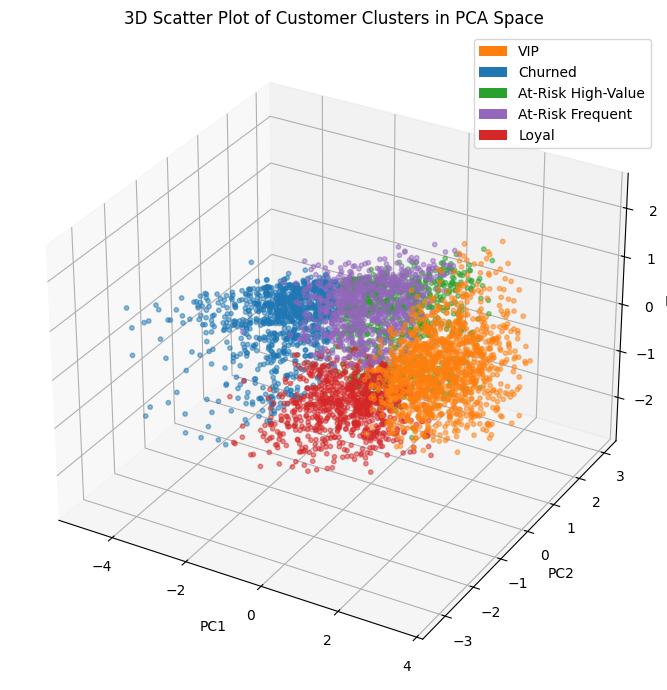

In [66]:
colors = non_outliers_df['Cluster'].map(cluster_labels_names).map(cluster_colors)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(projection='3d')

ax.scatter(pca_data[:, 0], 
           pca_data[:, 1], 
           pca_data[:, 2],
           c=colors,
           marker='o',
           alpha=0.5, s=10)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D Scatter Plot of Customer Clusters in PCA Space')

legend_elements = [Patch(facecolor=color, label=label) 
for label, color in cluster_colors.items()]

ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

VIP (ORANGE) — CLEAR SEPARATION ON THE RIGHT, WELL DISTINCT

CHURNED (BLUE) — SITS MOSTLY ON THE LEFT, REASONABLY DISTINCT

LOYAL (RED) — SITS BELOW VIP, PARTIALLY OVERLAPS ON PC1 BUT SEPARATED ON PC2/PC3

AT-RISK HIGH-VALUE (GREEN) AND AT-RISK FREQUENT (PURPLE) — HEAVILY OVERLAP WITH EACH OTHER AND WITH CHURNED IN THE CENTER-LEFT AREA

NOTE: OVERLAP IS EXPECTED FOR CUSTOMER SEGMENTATION DATA — DISTINCTION IS BUSINESS-DRIVEN RATHER THAN PURELY ALGORITHMIC. CONFIRMS WEAK BUT ACCEPTABLE SILHOUETTE SCORES.

In [67]:
outlier_clusters_df = pd.concat([monetary_outliers_df, frequency_outliers_df, aov_outliers_df]).drop_duplicates()

print(outlier_clusters_df[["MonetaryValue", "Frequency", "Recency", "AOV"]].describe())

outlier_transformed = pt.transform(outlier_clusters_df[["MonetaryValue", "Frequency", "Recency", "Tenure", "AOV"]])
outlier_transformed_df = pd.DataFrame(outlier_transformed, columns=["MonetaryValue", "Frequency", "Recency", "Tenure", "AOV"])
outlier_transformed_df = outlier_transformed_df[["MonetaryValue", "Frequency", "Recency", "AOV"]]

outlier_pca = pca.transform(outlier_transformed_df)
outlier_clusters_df["Cluster"] = kmeans.predict(outlier_pca)

       MonetaryValue  Frequency  Recency      AOV
count         904.00     904.00   904.00   904.00
mean        13070.54      19.89    95.26   986.68
std         34610.27      27.85   154.91  3107.24
min           768.24       1.00     0.00    28.67
25%          4004.53       4.00     7.00   371.60
50%          6551.70      15.00    24.00   633.10
75%         11101.60      24.00    86.25   969.75
max        580987.04     373.00   730.00 84236.25


In [68]:
full_clustering_df = pd.concat([
    non_outliers_df[["Cluster"]],
    outlier_clusters_df[["Cluster"]]
])

full_clustering_df["ClusterLabel"] = full_clustering_df["Cluster"].map(cluster_labels_names)
full_clustering_df

,Cluster,ClusterLabel
1,1,VIP
2,1,VIP
4,4,At-Risk High-Value
5,4,At-Risk High-Value
6,1,VIP
...,...,...
5485,4,At-Risk High-Value
5590,4,At-Risk High-Value
5643,1,VIP
5697,4,At-Risk High-Value


In [69]:
full_clustering_df["IsWhale"] = (
    full_clustering_df.index.isin(outlier_clusters_df[outlier_clusters_df["Cluster"] == vip_cluster].index)
)

VIP SUB-SEGMENT: WHALES (| STATISTICAL OUTLIERS | B2B/WHOLESALE BUYERS)

In [70]:
print(f"Non-outliers VIP: {(non_outliers_df['Cluster'] == vip_cluster).sum()}")
print(f"Outliers assigned to VIP: {(outlier_clusters_df['Cluster'] == vip_cluster).sum()}")
print(non_outliers_df[non_outliers_df["Cluster"] == vip_cluster][["MonetaryValue", "Frequency", "Recency", "AOV"]].describe())
print(outlier_clusters_df[outlier_clusters_df["Cluster"] == vip_cluster][["MonetaryValue", "Frequency", "Recency", "AOV"]].mean())

Non-outliers VIP: 1338
Outliers assigned to VIP: 722
       MonetaryValue  Frequency  Recency     AOV
count        1338.00    1338.00  1338.00 1338.00
mean         2460.64       7.50    55.04  354.83
std          1044.06       3.30    70.02  130.78
min           971.74       2.00     0.00  111.48
25%          1583.04       5.00    14.00  258.01
50%          2239.61       7.00    31.00  334.78
75%          3174.09      10.00    70.00  429.15
max          5087.86      16.00   575.00  759.00
MonetaryValue   15311.96
Frequency          24.42
Recency            43.13
AOV               662.41
dtype: float64


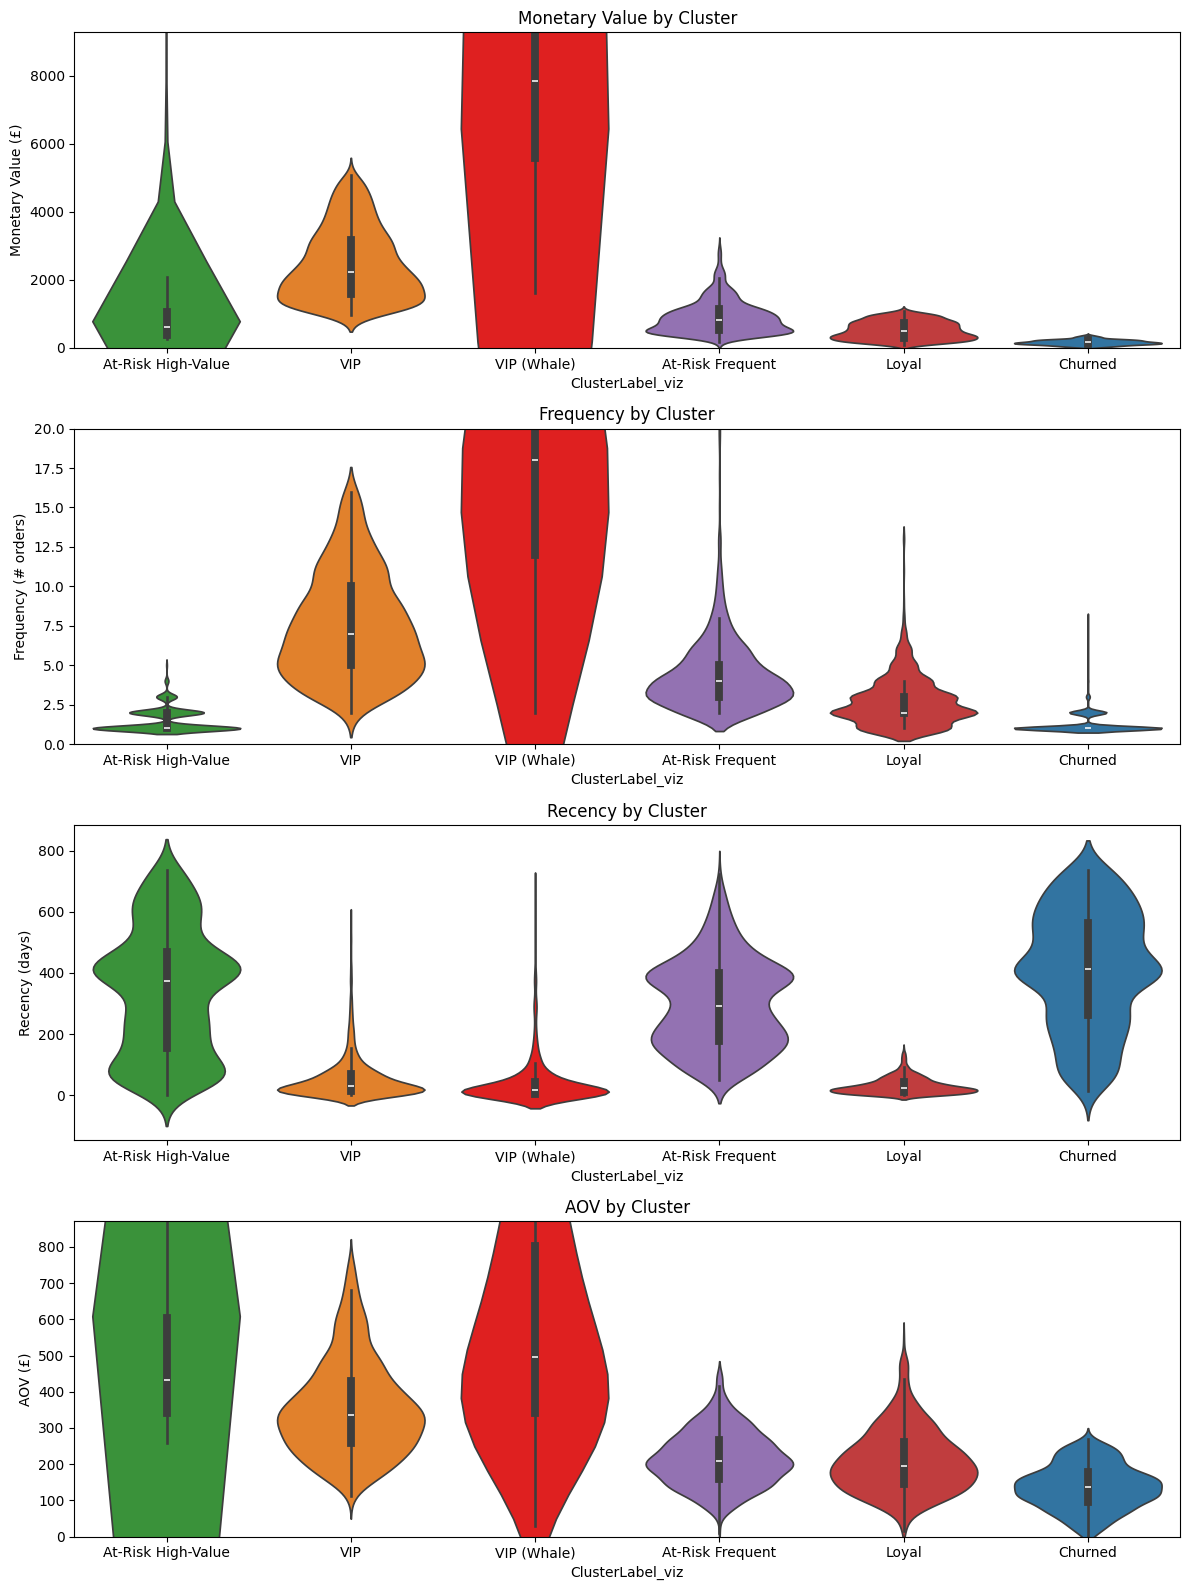

In [71]:
violin_df = aggregated_df.loc[aggregated_df.index.isin(full_clustering_df.index)].join(full_clustering_df[['ClusterLabel', 'IsWhale']], how='inner')

violin_df["ClusterLabel_viz"] = violin_df.apply(lambda r: "VIP (Whale)" if r["IsWhale"] else r["ClusterLabel"], axis=1)
cluster_colors_viz = {**cluster_colors, "VIP (Whale)": "#ff0000"}

plt.figure(figsize=(12, 16))
plt.subplot(4, 1, 1)
sns.violinplot(x=violin_df['ClusterLabel_viz'], y=violin_df['MonetaryValue'], hue=violin_df['ClusterLabel_viz'], palette=cluster_colors_viz, legend=False)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary Value (£)')
plt.ylim(0, violin_df['MonetaryValue'].quantile(0.95))
plt.subplot(4, 1, 2)
sns.violinplot(x=violin_df['ClusterLabel_viz'], y=violin_df['Frequency'], hue=violin_df['ClusterLabel_viz'], palette=cluster_colors_viz, legend=False)
plt.title('Frequency by Cluster')
plt.ylabel('Frequency (# orders)')
plt.ylim(0, violin_df['Frequency'].quantile(0.95))
plt.subplot(4, 1, 3)
sns.violinplot(x=violin_df['ClusterLabel_viz'], y=violin_df['Recency'], hue=violin_df['ClusterLabel_viz'], palette=cluster_colors_viz, legend=False)
plt.title('Recency by Cluster')
plt.ylabel('Recency (days)')
plt.subplot(4, 1, 4)
sns.violinplot(x=violin_df['ClusterLabel_viz'], y=violin_df['AOV'], hue=violin_df['ClusterLabel_viz'], palette=cluster_colors_viz, legend=False)
plt.title('AOV by Cluster')
plt.ylabel('AOV (£)')
plt.ylim(0, violin_df['AOV'].quantile(0.95))
plt.tight_layout()
plt.show()

MONETARYVALUE — VIP CLEARLY HIGHEST, CHURNED LOWEST, AT-RISK HIGH-VALUE SURPRISINGLY HIGH DUE TO OUTLIERS. WELL SEPARATED.

FREQUENCY — VIP HIGHEST, AT-RISK HIGH-VALUE AND CHURNED VERY LOW. AT-RISK FREQUENT SHOWS WIDER DISTRIBUTION — CONFIRMS MID-FREQUENCY BUYERS. VIP (WHALE) SHOWS EXTREME FREQUENCY — CONFIRMS B2B/WHOLESALE BEHAVIOR.

RECENCY — CHURNED AND AT-RISK BOTH HIGH (DISENGAGED), VIP AND VIP (WHALE) LOWEST (MOST RECENT), LOYAL VERY LOW. AT-RISK HIGH-VALUE AND AT-RISK FREQUENT OVERLAP HEAVILY ON RECENCY — KEY DISTINCTION IS AOV AND FREQUENCY.

AOV — VIP (WHALE) CLEARLY HIGHEST, CONFIRMING EXTREME PER-ORDER SPEND. AT-RISK HIGH-VALUE AND CORE VIP BOTH HIGH, AT-RISK FREQUENT, LOYAL AND CHURNED LOWER. AOV IS WHAT SEPARATES AT-RISK HIGH-VALUE FROM AT-RISK FREQUENT — KEY DISTINGUISHING FEATURE.

In [72]:
for col in ["MonetaryValue", "Frequency", "Recency", "AOV"]:
    groups = [violin_df[violin_df["ClusterLabel_viz"] == label][col] for label in violin_df["ClusterLabel_viz"].unique()]
    stat, p = kruskal(*groups)
    print(f"{col}: H-stat={stat:.2f}, p={p:.2e}")

MonetaryValue: H-stat=4822.69, p=0.00e+00
Frequency: H-stat=4547.41, p=0.00e+00
Recency: H-stat=3764.62, p=0.00e+00
AOV: H-stat=3538.12, p=0.00e+00


ALL FOUR FEATURES DIFFER SIGNIFICANTLY ACROSS ALL 6 SEGMENTS INCLUDING VIP (WHALE) (KRUSKAL-WALLIS, p ≈ 0 FOR ALL). CLUSTER SEPARATION IS STATISTICALLY CONFIRMED.

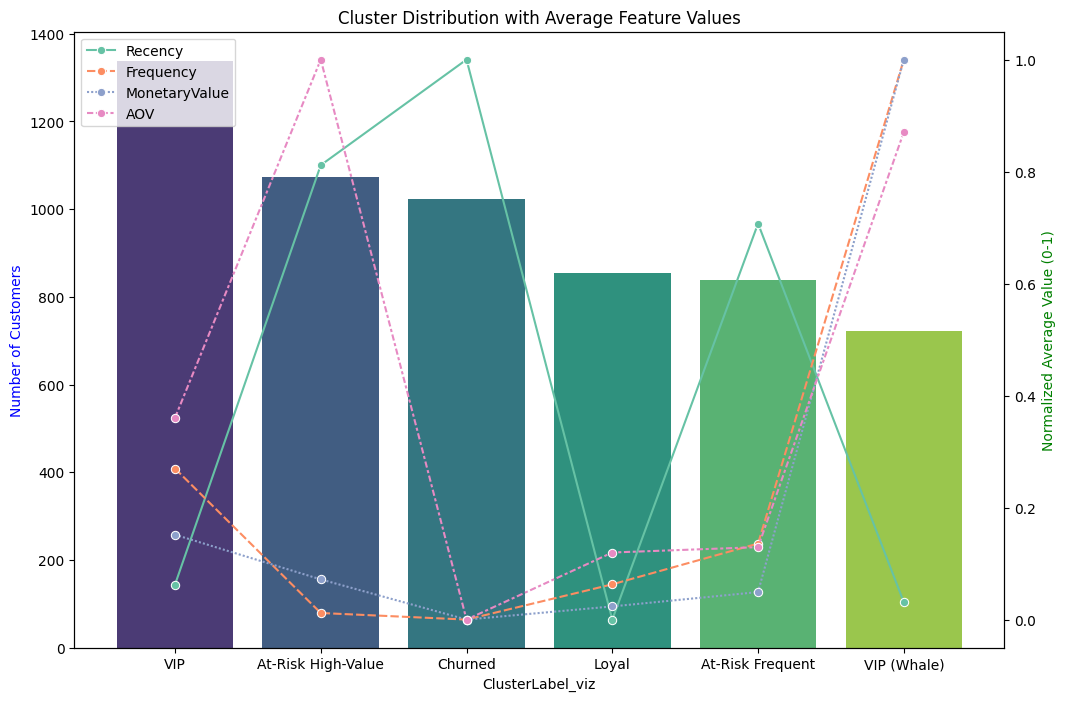

In [73]:
cluster_counts = violin_df['ClusterLabel_viz'].value_counts()

feature_means = violin_df.groupby('ClusterLabel_viz')[['Recency', 'Frequency', 'MonetaryValue', 'AOV']].mean()
feature_means = feature_means.reindex(cluster_counts.index)

feature_means_viz = (feature_means - feature_means.min()) / (feature_means.max() - feature_means.min())
feature_means_viz = feature_means_viz.reindex(cluster_counts.index)

fig, ax1 = plt.subplots(figsize=(12, 8))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, ax=ax1, palette='viridis', hue=cluster_counts.index)
ax1.set_ylabel('Number of Customers', color='b')
ax1.set_title('Cluster Distribution with Average Feature Values')

ax2 = ax1.twinx()
sns.lineplot(data=feature_means_viz, ax=ax2, palette='Set2', marker='o')
ax2.set_ylabel('Normalized Average Value (0-1)', color='g')

plt.show()

VIP (1,338 CUSTOMERS) — LARGEST CORE SEGMENT, HIGHEST FREQUENCY, LOWEST RECENCY, HIGH MONETARY

VIP (WHALE) (722 CUSTOMERS) — HIGHEST MONETARYVALUE AND AOV — EXTREME SPENDERS. LOWEST RECENCY — MOST ACTIVE. CONFIRMS B2B/WHOLESALE BEHAVIOR.

AT-RISK HIGH-VALUE (1054) — HIGH AOV, VERY HIGH RECENCY — DISENGAGED HIGH-SPENDERS

CHURNED (1024) — HIGHEST RECENCY, LOWEST FREQUENCY AND MONETARY — INACTIVE LOW-VALUE

LOYAL (855) — LOW RECENCY (ACTIVE), LOW MONETARY AND FREQUENCY — REGULAR BUT LOW-SPEND

AT-RISK FREQUENT (839) — HIGH RECENCY, MID AOV (£216), HIGHEST FREQUENCY AMONG AT-RISK — FORMERLY REGULAR BUYERS NOW DISENGAGED

In [74]:
print(feature_means)

                    Recency  Frequency  MonetaryValue    AOV
ClusterLabel_viz                                            
VIP                   55.04       7.50        2460.64 354.83
At-Risk High-Value   338.46       1.52        1251.77 740.34
Churned              409.80       1.25         164.77 137.70
Loyal                 31.46       2.71         520.80 209.88
At-Risk Frequent     299.02       4.40         908.92 215.66
VIP (Whale)           43.13      24.42       15311.96 662.41


In [75]:
revenue_share = violin_df.groupby('ClusterLabel_viz')['MonetaryValue'].sum()
revenue_share_pct = (revenue_share / revenue_share.sum() * 100).round(1)
print(revenue_share_pct)

ClusterLabel_viz
At-Risk Frequent      4.50
At-Risk High-Value    7.90
Churned               1.00
Loyal                 2.60
VIP                  19.30
VIP (Whale)          64.80
Name: MonetaryValue, dtype: float64


REVENUE SHARE: VIP (WHALE) 64.8%, VIP (CORE) 19.3%, AT-RISK HIGH-VALUE 7.9%, AT-RISK FREQUENT 4.5%, LOYAL 2.6%, CHURNED 1.0%. WHALES ALONE GENERATE 64.8% OF TOTAL REVENUE — DEDICATED B2B ACCOUNT MANAGEMENT IS THE SINGLE HIGHEST-PRIORITY ACTION. CORE VIP RETENTION IS SECOND. AT-RISK HIGH-VALUE RE-ENGAGEMENT THIRD.

In [76]:
print(violin_df['ClusterLabel_viz'].value_counts())

ClusterLabel_viz
VIP                   1338
At-Risk High-Value    1074
Churned               1024
Loyal                  855
At-Risk Frequent       839
VIP (Whale)            722
Name: count, dtype: int64


**FINAL BUSINESS RECOMMENDATIONS**:



VIP CORE (1,338 CUSTOMERS | £2,461 AVG SPEND | 7.5 ORDERS | 55 DAYS RECENCY| £355 AOV) — RETAIN AND REWARD. LOYALTY PROGRAMS, EARLY ACCESS, EXCLUSIVE PREVIEWS.

VIP WHALE (722 CUSTOMERS | £15,312 AVG SPEND | 24.4 ORDERS | 43 DAYS RECENCY | £662 AOV) — DEDICATED ACCOUNT MANAGERS, B2B/WHOLESALE PRICING, VOLUME DISCOUNT CONTRACTS, NET-30/60 PAYMENT TERMS, DIRECT SUPPORT CHANNEL. DO NOT TREAT WITH MASS CAMPAIGNS.

LOYAL (855 CUSTOMERS | £521 AVG SPEND | 2.71 ORDERS | 31 DAYS RECENCY) — NURTURE AND UPSELL. MOST RECENTLY ACTIVE SEGMENT. CROSS-SELL COMPLEMENTARY PRODUCTS AND INTRODUCE PREMIUM LINES TO MIGRATE TOWARD VIP.

AT-RISK HIGH-VALUE (1,074 CUSTOMERS | £1,252 AVG SPEND | 1.52 ORDERS | 338 DAYS RECENCY) — RE-ENGAGE URGENTLY. HIGHEST AOV (£740) — THEY SPEND BIG WHEN THEY BUY. PERSONALIZED WIN-BACK CAMPAIGNS AND EXCLUSIVE DISCOUNTS BEFORE FULL CHURN.

AT-RISK FREQUENT (839 CUSTOMERS | £909 AVG SPEND | 4.40 ORDERS | 299 DAYS RECENCY) — VOLUME INCENTIVES. WERE REGULAR BUYERS — BUNDLE DEALS AND "WE MISS YOU" CAMPAIGNS TO REACTIVATE PURCHASE HABITS.

CHURNED (1,024 CUSTOMERS | £165 AVG SPEND | 1.25 ORDERS | 410 DAYS RECENCY) — LOW-COST RE-ENGAGEMENT ONLY. AUTOMATED EMAIL WITH STRONG INCENTIVES. DEPRIORITIZE IF NO RESPONSE AFTER 2-3 ATTEMPTS.

<h2 style="text-align: center">INFERENCE DEMO</h2>

In [77]:
joblib.dump(pt, '../artifacts/power_transformer.pkl')
joblib.dump(pca, '../artifacts/pca.pkl')
joblib.dump(kmeans, '../artifacts/kmeans_k5.pkl')
joblib.dump(max_invoice_date, '../artifacts/reference_date.pkl')
joblib.dump(cluster_labels_names, '../artifacts/cluster_labels_names.pkl')
joblib.dump({
    'M_Q1': M_Q1, 'M_Q3': M_Q3, 'M_IQR': M_IQR,
    'F_Q1': F_Q1, 'F_Q3': F_Q3, 'F_IQR': F_IQR,
    'AOV_Q1': AOV_Q1, 'AOV_Q3': AOV_Q3, 'AOV_IQR': AOV_IQR
}, '../artifacts/iqr_bounds.pkl')              

['../artifacts/iqr_bounds.pkl']

In [78]:
# Load artifacts
pt = joblib.load('../artifacts/power_transformer.pkl')
pca = joblib.load('../artifacts/pca.pkl')
kmeans = joblib.load('../artifacts/kmeans_k5.pkl')
iqr_bounds = joblib.load('../artifacts/iqr_bounds.pkl')
reference_date = joblib.load('../artifacts/reference_date.pkl')
cluster_labels_names = joblib.load('../artifacts/cluster_labels_names.pkl')

# New customers (raw values)
customers_raw = pd.DataFrame([
    {'last_purchase': '2011-11-20', 'first_purchase': '2011-01-01', 'MonetaryValue': 3000.0, 'Frequency': 10, 'AOV': 400.0},   # VIP
    {'last_purchase': '2011-11-08', 'first_purchase': '2011-06-01', 'MonetaryValue': 521.0,  'Frequency': 3,  'AOV': 210.0},   # Loyal
    {'last_purchase': '2011-07-01', 'first_purchase': '2011-04-01', 'MonetaryValue': 700.0,  'Frequency': 1,  'AOV': 600.0},   # At-Risk High-Value
    {'last_purchase': '2011-06-01', 'first_purchase': '2011-05-01', 'MonetaryValue': 150.0,  'Frequency': 1,  'AOV': 80.0},    # Churned
    {'last_purchase': '2011-04-01', 'first_purchase': '2010-12-01', 'MonetaryValue': 900.0,  'Frequency': 4,  'AOV': 225.0},   # At-Risk Frequent
    {'last_purchase': '2011-09-01', 'first_purchase': '2011-05-01', 'MonetaryValue': 600.0,  'Frequency': 2,  'AOV': 450.0},   # Borderline
    {'last_purchase': '2011-11-20', 'first_purchase': '2010-12-01', 'MonetaryValue': 10000.0,'Frequency': 100,'AOV': 1000.0},  # Outlier
])

customers_raw['last_purchase'] = pd.to_datetime(customers_raw['last_purchase'])
customers_raw['first_purchase'] = pd.to_datetime(customers_raw['first_purchase'])
customers_raw['Recency'] = (reference_date - customers_raw['last_purchase']).dt.days
customers_raw['Tenure'] = (customers_raw['last_purchase'] - customers_raw['first_purchase']).dt.days
customers = customers_raw[['MonetaryValue', 'Frequency', 'Recency', 'Tenure', 'AOV']]


# Outlier flag
def is_outlier(row):
    return (
        row['MonetaryValue'] > iqr_bounds['M_Q3'] + 1.5 * iqr_bounds['M_IQR'] or
        row['Frequency']     > iqr_bounds['F_Q3'] + 1.5 * iqr_bounds['F_IQR'] or
        row['AOV']           > iqr_bounds['AOV_Q3'] + 1.5 * iqr_bounds['AOV_IQR']
    )

customers_raw['is_outlier'] = customers.apply(is_outlier, axis=1)

# Transform
transformed = pt.transform(customers)
transformed_df = pd.DataFrame(transformed, columns=['MonetaryValue', 'Frequency', 'Recency', 'Tenure', 'AOV'])
transformed_df = transformed_df[['MonetaryValue', 'Frequency', 'Recency', 'AOV']]

# PCA + predict
pca_input = pca.transform(transformed_df)
clusters = kmeans.predict(pca_input)

labels = ['VIP', 'Loyal', 'At-Risk High-Value', 'Churned', 'At-Risk Frequent', 'Borderline','Outlier']
for i, cluster in enumerate(clusters):
    outlier_flag = '⚠️ OUTLIER' if customers_raw['is_outlier'].iloc[i] else ''
    whale_flag = '🐋 WHALE' if (customers_raw['is_outlier'].iloc[i] and cluster_labels_names[cluster] == 'VIP') else ''
    print(f"Customer {i+1} ({labels[i]}): Cluster {cluster} — {cluster_labels_names[cluster]} {outlier_flag} {whale_flag}")

Customer 1 (VIP): Cluster 1 — VIP  
Customer 2 (Loyal): Cluster 0 — Loyal  
Customer 3 (At-Risk High-Value): Cluster 4 — At-Risk High-Value  
Customer 4 (Churned): Cluster 2 — Churned  
Customer 5 (At-Risk Frequent): Cluster 3 — At-Risk Frequent  
Customer 6 (Borderline): Cluster 4 — At-Risk High-Value  
Customer 7 (Outlier): Cluster 1 — VIP ⚠️ OUTLIER 🐋 WHALE


ALL 7 TARGETED CUSTOMERS LANDED IN THEIR INTENDED CLUSTERS, CONFIRMING THE INFERENCE PIPELINE WORKS CORRECTLY END-TO-END.
CUSTOMER 7 (OUTLIER) CORRECTLY CLASSIFIED AS VIP AND FLAGGED WITH ⚠️ OUTLIER — OUTLIER DETECTION PIPELINE WORKS.

BORDERLINE CASE (CUSTOMER 6): HIGH AOV (£450) AND LOW FREQUENCY (2) ASSIGNED TO AT-RISK HIGH-VALUE DESPITE MODERATE RECENCY — ALIGNS WITH THE CLUSTER'S CORE TRAIT.

<h2 style="text-align: center">EXPORT</h2>

In [79]:
# Clustered customer data for marketing team
violin_df.to_excel('../outputs/customer_segments.xlsx', index=True)

# Cluster summary statistics
feature_means.to_excel('../outputs/cluster_summary.xlsx', index=True)

EXPORT TO EXCEL — FOR MARKETING AND MANAGEMENT TEAM

<h2 style="text-align: center">LIMITATIONS</h2>

LIMITATIONS:

1. SILHOUETTE SCORES ARE WEAK (0.28–0.36) (CUSTOMER BEHAVIOR IS INHERENTLY 
CONTINUOUS AND OVERLAP BETWEEN CLUSTERS IS EXPECTED)

2. DATA IS FROM 2009-2011 — MODEL MAY NOT GENERALIZE TO CURRENT CUSTOMER BEHAVIOR 
(FOR THAT NEEDS RETRAINING)

3. MONETARYVALUE = AOV × FREQUENCY — ALGEBRAIC REDUNDANCY IN FEATURES
(PARTIALLY MITIGATED BY PCA DECORRELATION, BUT AOV IS CRITICAL FOR SEPARATING AT-RISK HIGH-VALUE FROM LOYAL CUSTOMERS, AND MONETARY SEPARATES VIP FROM EVERYONE ELSE)

4. FREQUENCY REMAINS MODERATELY RIGHT-SKEWED AFTER YEO-JOHNSON TRANSFORMATION — 
A KNOWN LIMITATION, BUT RETAINED DUE TO ITS ROLE AS A CORE RFM METRIC AND ITS 
ABILITY TO DISTINGUISH AT-RISK FREQUENT FROM OTHER SEGMENTS.

5. REFERENCE DATE IS FIXED TO THE TRAINING DATA (2011-12-09) — IN PRODUCTION, 
RECENCY CALCULATIONS WOULD REQUIRE UPDATING THE REFERENCE DATE TO THE CURRENT DATE, 
OTHERWISE ALL RECENCY VALUES WILL BE SYSTEMATICALLY INFLATED OVER TIME.


THIS LIMITATIONS ARE EXPLAINED MORE THOROUGHLY IN MARKDOWN CELLS IN THIS PROJECT ABOVE